# Análisis Exploratorio de Datos (EDA)
## Sistema OSINT ML1 — Conflicto Irán–Israel–EE.UU.

**Universidad Externado de Colombia · Machine Learning 1 (ML1-2026I)**

---

### Pregunta analítica
> ¿Es posible clasificar el **nivel de escalada** del conflicto Irán–Israel–EE.UU. en ventanas **país-día** usando exclusivamente fuentes abiertas y gratuitas: eventos estructurados (GDELT), imágenes satelitales (FIRMS), noticias (RSS), movilidad aérea (OpenSky) y señales sociales (Bluesky)?

### Arquitectura del sistema de datos

| Capa | Componente | Descripción |
|---|---|---|
| Fuentes raw | GDELT / FIRMS / RSS / OpenSky / Bluesky | Ingesta multifuente |
| Almacenamiento | Supabase (PostgreSQL) | `raw_events`, tablas especializadas, vistas |
| Features | `features.parquet` | 183 ventanas país-día procesadas |
| Target | `escalation_level` (0=Bajo, 1=Medio, 2=Alto) | Definido por cuartiles GDELT por país |
| Modelos | KNN, Logistic Regression, Ridge, Naive Bayes | Evaluación CV 5-fold |

**Período analizado:** Enero 2024 – Mayo 2026  
**Países:** IRN (Irán), ISR (Israel), USA (EE.UU.)  
**Unidad de análisis:** Ventana país-día

In [1]:
# ── Imports y configuración global ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json

# Estilo visual coherente
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#cbd5e1',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#334155',
    'grid.alpha':       0.5,
    'figure.dpi':       120,
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})
sns.set_palette('husl')

COUNTRY_COLORS = {'IRN': '#ef4444', 'ISR': '#3b82f6', 'USA': '#22c55e'}
LEVEL_COLORS   = {0: '#22c55e', 1: '#eab308', 2: '#ef4444'}
LEVEL_LABELS   = {0: 'Bajo (0)', 1: 'Medio (1)', 2: 'Alto (2)'}

ROOT = Path('..')   # raíz del proyecto
DATA = ROOT / 'data'
ART  = ROOT / 'artifacts'

print('✓ Entorno configurado correctamente')

✓ Entorno configurado correctamente


---
## 1. Inventario general de la base de datos (Supabase)

El sistema almacena datos en **Supabase (PostgreSQL)** con 8 migraciones aplicadas.  
La tabla `raw_events` es el repositorio principal; las tablas `events_*` contienen datos normalizados por fuente.

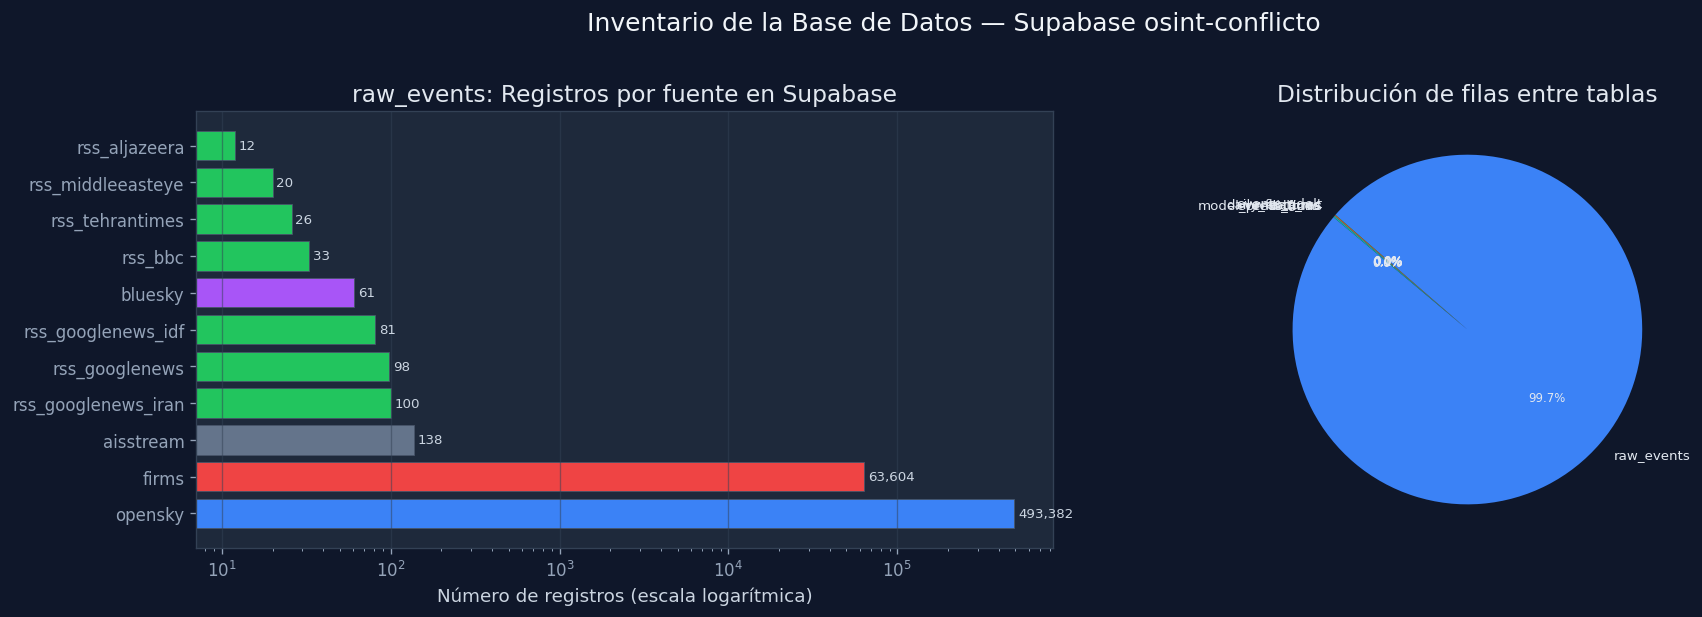


Total registros raw_events: 557,555
Tablas con datos: 7
Vistas SQL: 5


In [2]:
# Inventario de la BD replicado desde Supabase (consultado vía MCP el 2026-05-31)
inventario = pd.DataFrame([
    {'Tabla / Vista',           'Filas',    'Descripción'},
])

db_inventory = {
    'raw_events':          {'filas': 557184, 'tipo': 'tabla',  'descripcion': 'Repositorio central de eventos crudos de todas las fuentes'},
    'events_gdelt':        {'filas': 120,    'tipo': 'tabla',  'descripcion': 'Eventos GDELT country-day agregados (IRN/ISR/USA)'},
    'events_rss':          {'filas': 141,    'tipo': 'tabla',  'descripcion': 'Titulares de BBC, Al Jazeera, Google News, Tehran Times, MEE'},
    'events_firms':        {'filas': 348,    'tipo': 'tabla',  'descripcion': 'Hotspots térmicos NASA FIRMS mayo 2026'},
    'daily_features':      {'filas': 183,    'tipo': 'tabla',  'descripcion': 'Features agregadas por país-día (fuente: pipeline ML)'},
    'model_predictions':   {'filas': 732,    'tipo': 'tabla',  'descripcion': '4 modelos × 183 ventanas = predicciones y métricas'},
    'sources':             {'filas': 15,     'tipo': 'tabla',  'descripcion': 'Catálogo de fuentes de datos activas'},
    'v_daily_dashboard':   {'filas': None,   'tipo': 'vista',  'descripcion': 'Join daily_features + model_predictions (KNN)'},
    'v_escalation_timeline':{'filas': None,  'tipo': 'vista',  'descripcion': 'Serie temporal por país × modelo'},
    'v_target_distribution':{'filas': None,  'tipo': 'vista',  'descripcion': 'Distribución de clases por país'},
    'v_gdelt_tone_timeline':{'filas': None,  'tipo': 'vista',  'descripcion': 'Tono Goldstein promedio por país en el tiempo'},
    'v_sources_status':    {'filas': None,   'tipo': 'vista',  'descripcion': 'Estado y cobertura de cada fuente'},
}

df_inv = pd.DataFrame(db_inventory).T.reset_index().rename(columns={'index': 'objeto'})

# Distribución por fuente en raw_events (datos reales de Supabase)
raw_sources = pd.DataFrame([
    {'source': 'opensky',            'n': 493382, 'desde': '2023-10-07', 'hasta': '2025-06-13'},
    {'source': 'firms',              'n': 63604,  'desde': '2023-10-07', 'hasta': '2026-05-14'},
    {'source': 'aisstream',          'n': 138,    'desde': '2026-05-14', 'hasta': '2026-05-14'},
    {'source': 'rss_googlenews_iran','n': 100,    'desde': '2026-02-26', 'hasta': '2026-05-14'},
    {'source': 'rss_googlenews',     'n': 98,     'desde': '2026-03-01', 'hasta': '2026-05-14'},
    {'source': 'rss_googlenews_idf', 'n': 81,     'desde': '2023-04-07', 'hasta': '2026-05-14'},
    {'source': 'bluesky',            'n': 61,     'desde': '2026-05-30', 'hasta': '2026-05-30'},
    {'source': 'rss_bbc',            'n': 33,     'desde': '2026-04-24', 'hasta': '2026-05-14'},
    {'source': 'rss_tehrantimes',    'n': 26,     'desde': '2026-05-10', 'hasta': '2026-05-11'},
    {'source': 'rss_middleeasteye',  'n': 20,     'desde': '2026-05-14', 'hasta': '2026-05-14'},
    {'source': 'rss_aljazeera',      'n': 12,     'desde': '2026-05-14', 'hasta': '2026-05-15'},
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica 1: Filas por fuente (raw_events) en escala log
ax = axes[0]
colors = ['#3b82f6' if s == 'opensky' else
          '#ef4444' if s == 'firms' else
          '#22c55e' if 'rss' in s else
          '#a855f7' if s == 'bluesky' else '#64748b'
          for s in raw_sources['source']]
bars = ax.barh(raw_sources['source'], raw_sources['n'], color=colors, edgecolor='#475569', linewidth=0.5)
ax.set_xscale('log')
ax.set_xlabel('Número de registros (escala logarítmica)')
ax.set_title('raw_events: Registros por fuente en Supabase')
ax.grid(axis='x')
for bar, n in zip(bars, raw_sources['n']):
    ax.text(n * 1.05, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center', fontsize=8, color='#cbd5e1')

# Gráfica 2: Inventario de tablas por tipo
ax2 = axes[1]
tablas = df_inv[df_inv['tipo'] == 'tabla']
vistas = df_inv[df_inv['tipo'] == 'vista']
tabla_names = tablas['objeto'].tolist()
tabla_filas = tablas['filas'].astype(float).tolist()
colors2 = ['#3b82f6','#22c55e','#eab308','#f97316','#a855f7','#14b8a6','#64748b']
wedges, texts, autotexts = ax2.pie(
    tabla_filas, labels=tabla_names, colors=colors2[:len(tabla_names)],
    autopct='%1.1f%%', startangle=140,
    textprops={'color': '#e2e8f0', 'fontsize': 8}
)
for a in autotexts: a.set_fontsize(7)
ax2.set_title('Distribución de filas entre tablas')

plt.suptitle('Inventario de la Base de Datos — Supabase osint-conflicto', 
             fontsize=15, y=1.02, color='#f1f5f9')
plt.tight_layout()
plt.show()

print(f'\nTotal registros raw_events: {raw_sources["n"].sum():,}')
print(f'Tablas con datos: {len(tablas)}')
print(f'Vistas SQL: {len(vistas)}')

---
## 2. Fuente principal: GDELT

**GDELT (Global Database of Events, Language, and Tone)** es la fuente principal del pipeline.  
Monitorea noticias globales y extrae eventos con la escala **Goldstein** (−10=conflicto máximo, +10=cooperación máxima).  

- **Cobertura:** Octubre 2014 – Mayo 2026 (285 registros country-day en el parquet raw, 120 en Supabase)
- **Granularidad:** 1 fila por país × día (agregado)
- **Variables clave:** `n_conflict_events`, `avg_goldstein`, `n_mentions`, `has_high_violence`

In [3]:
gdelt = pd.read_parquet(DATA / 'raw/gdelt/gdelt_raw.parquet')
gdelt['event_date'] = pd.to_datetime(gdelt['event_date'])
gdelt = gdelt.sort_values('event_date')

print(f'Shape: {gdelt.shape}')
print(f'Rango temporal: {gdelt["event_date"].min().date()} → {gdelt["event_date"].max().date()}')
print(f'Países: {gdelt["country"].unique()}')
print(f'has_high_violence siempre True: {gdelt["has_high_violence"].all()}')
print(f'\nEstadísticas descriptivas:')
gdelt[['n_conflict_events','avg_goldstein','n_mentions']].describe().round(2)

Shape: (285, 6)
Rango temporal: 2014-10-04 → 2026-05-10
Países: <ArrowStringArray>
['IRN', 'USA', 'ISR']
Length: 3, dtype: str
has_high_violence siempre True: True

Estadísticas descriptivas:


,n_conflict_events,avg_goldstein,n_mentions
count,285.00,285.00,285.00
mean,8523.87,2.90,167131.81
std,8099.13,0.79,146201.90
min,364.00,1.24,3878.00
25%,2193.00,2.42,41590.00
50%,4824.00,2.67,114295.00
75%,13810.00,3.30,277543.00
max,26625.00,5.24,499085.00


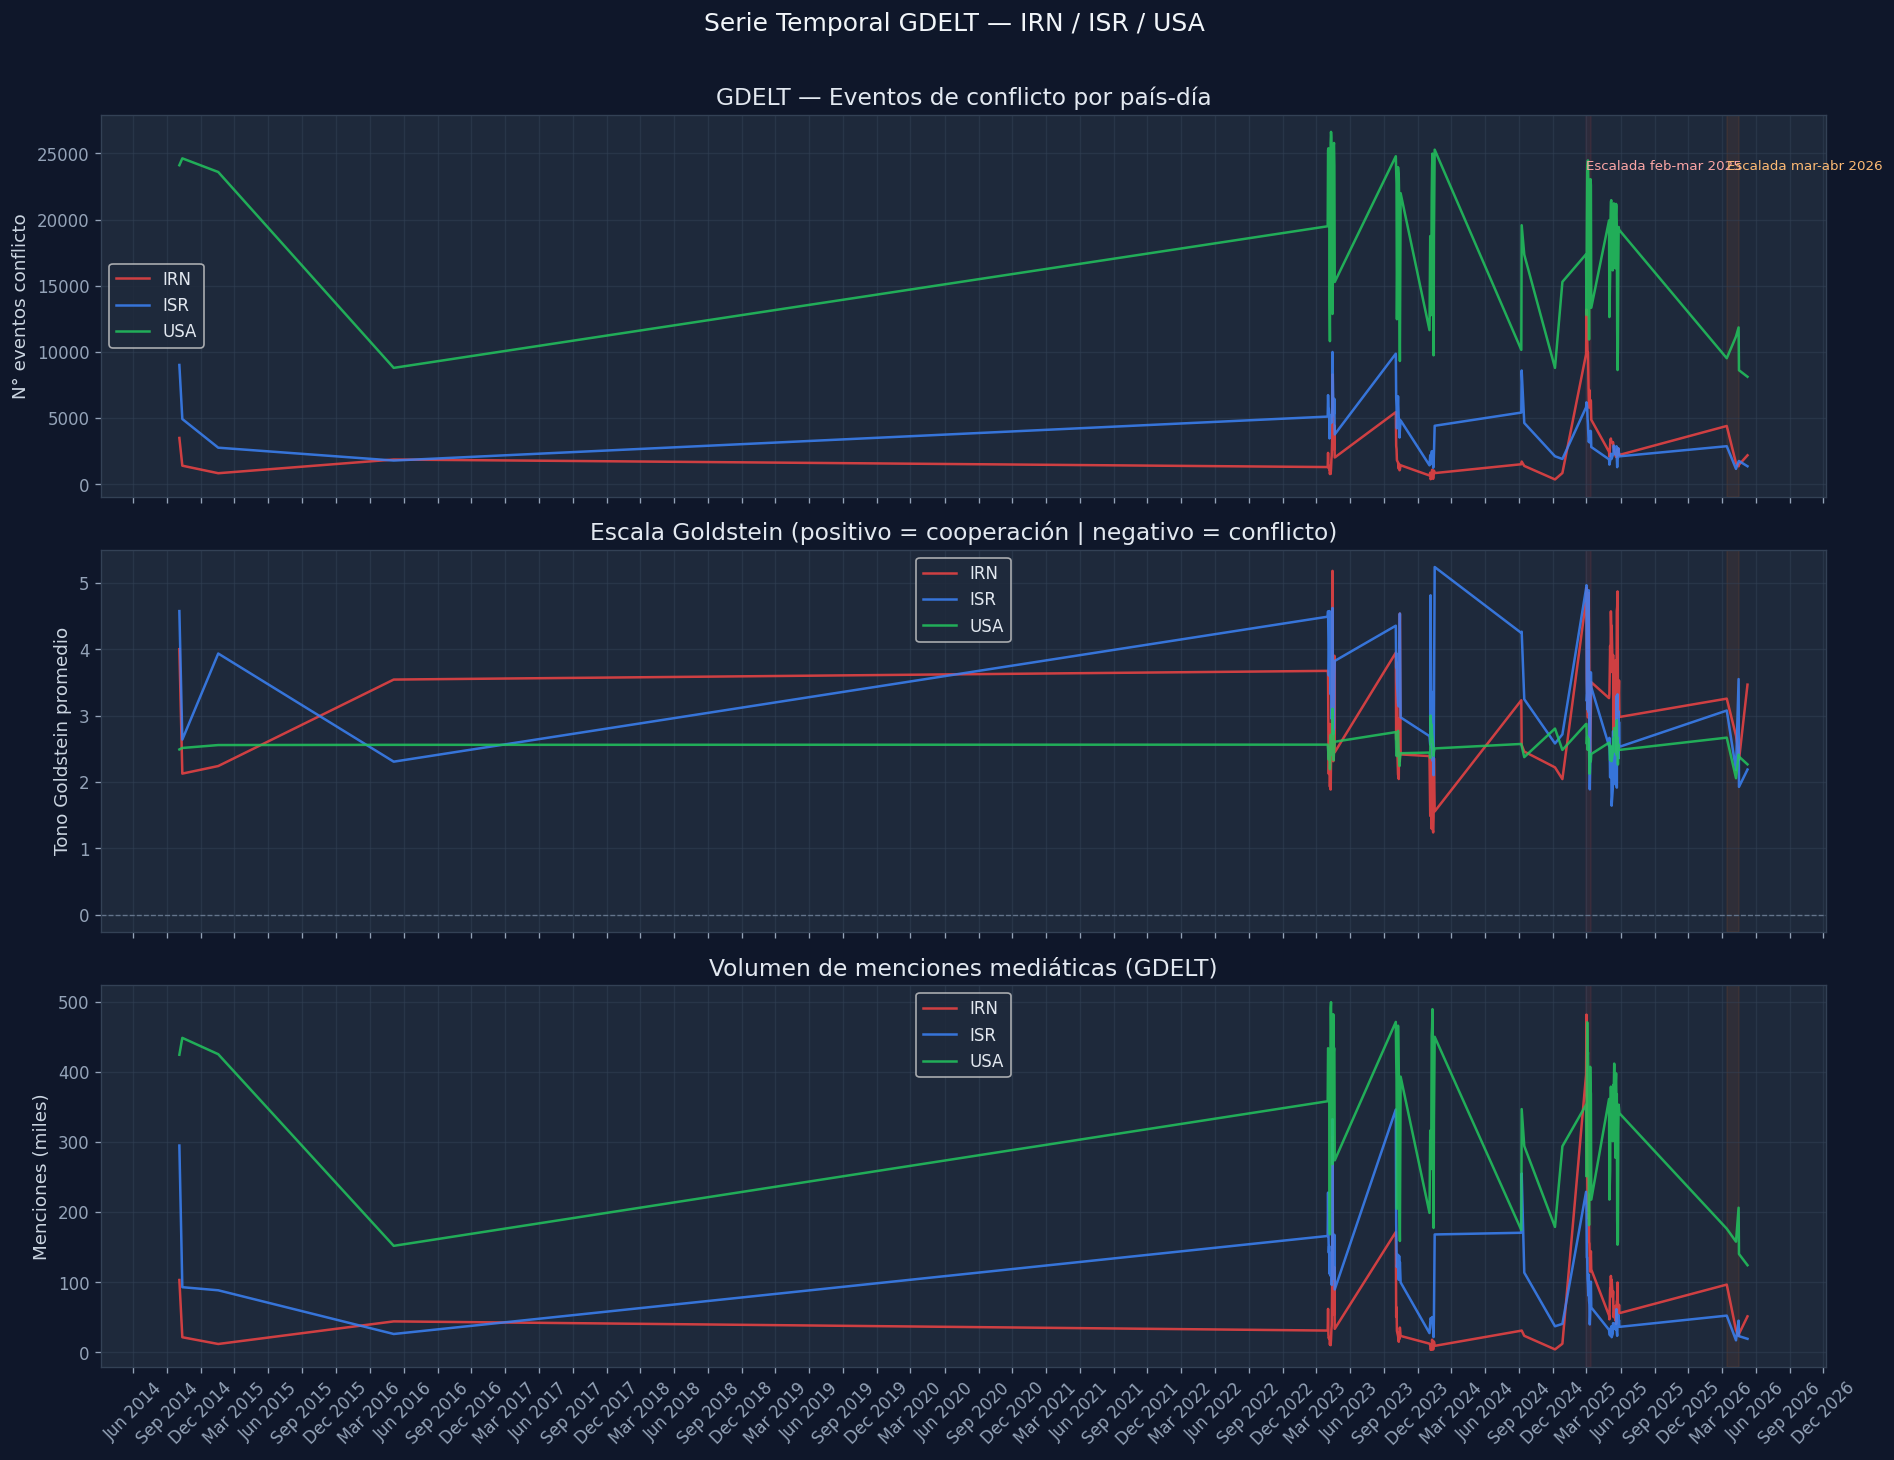

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for country, color in COUNTRY_COLORS.items():
    sub = gdelt[gdelt['country'] == country]
    
    axes[0].plot(sub['event_date'], sub['n_conflict_events'], 
                 label=country, color=color, linewidth=1.5, alpha=0.85)
    axes[1].plot(sub['event_date'], sub['avg_goldstein'],
                 label=country, color=color, linewidth=1.5, alpha=0.85)
    axes[2].plot(sub['event_date'], sub['n_mentions'] / 1e3,
                 label=country, color=color, linewidth=1.5, alpha=0.85)

axes[0].set_ylabel('N° eventos conflicto')
axes[0].set_title('GDELT — Eventos de conflicto por país-día')
axes[0].legend()
axes[0].grid()

axes[1].axhline(0, color='#64748b', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Tono Goldstein promedio')
axes[1].set_title('Escala Goldstein (positivo = cooperación | negativo = conflicto)')
axes[1].legend()
axes[1].grid()

axes[2].set_ylabel('Menciones (miles)')
axes[2].set_title('Volumen de menciones mediáticas (GDELT)')
axes[2].legend()
axes[2].grid()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

# Anotaciones de eventos clave
for ax in axes:
    ax.axvspan(pd.Timestamp('2025-02-28'), pd.Timestamp('2025-03-14'), 
               alpha=0.08, color='#ef4444', label='_nolegend_')
    ax.axvspan(pd.Timestamp('2026-03-15'), pd.Timestamp('2026-04-17'),
               alpha=0.08, color='#f97316', label='_nolegend_')

axes[0].text(pd.Timestamp('2025-02-28'), axes[0].get_ylim()[1]*0.85,
             'Escalada feb-mar 2025', fontsize=8, color='#fca5a5')
axes[0].text(pd.Timestamp('2026-03-15'), axes[0].get_ylim()[1]*0.85,
             'Escalada mar-abr 2026', fontsize=8, color='#fdba74')

plt.suptitle('Serie Temporal GDELT — IRN / ISR / USA', fontsize=15, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

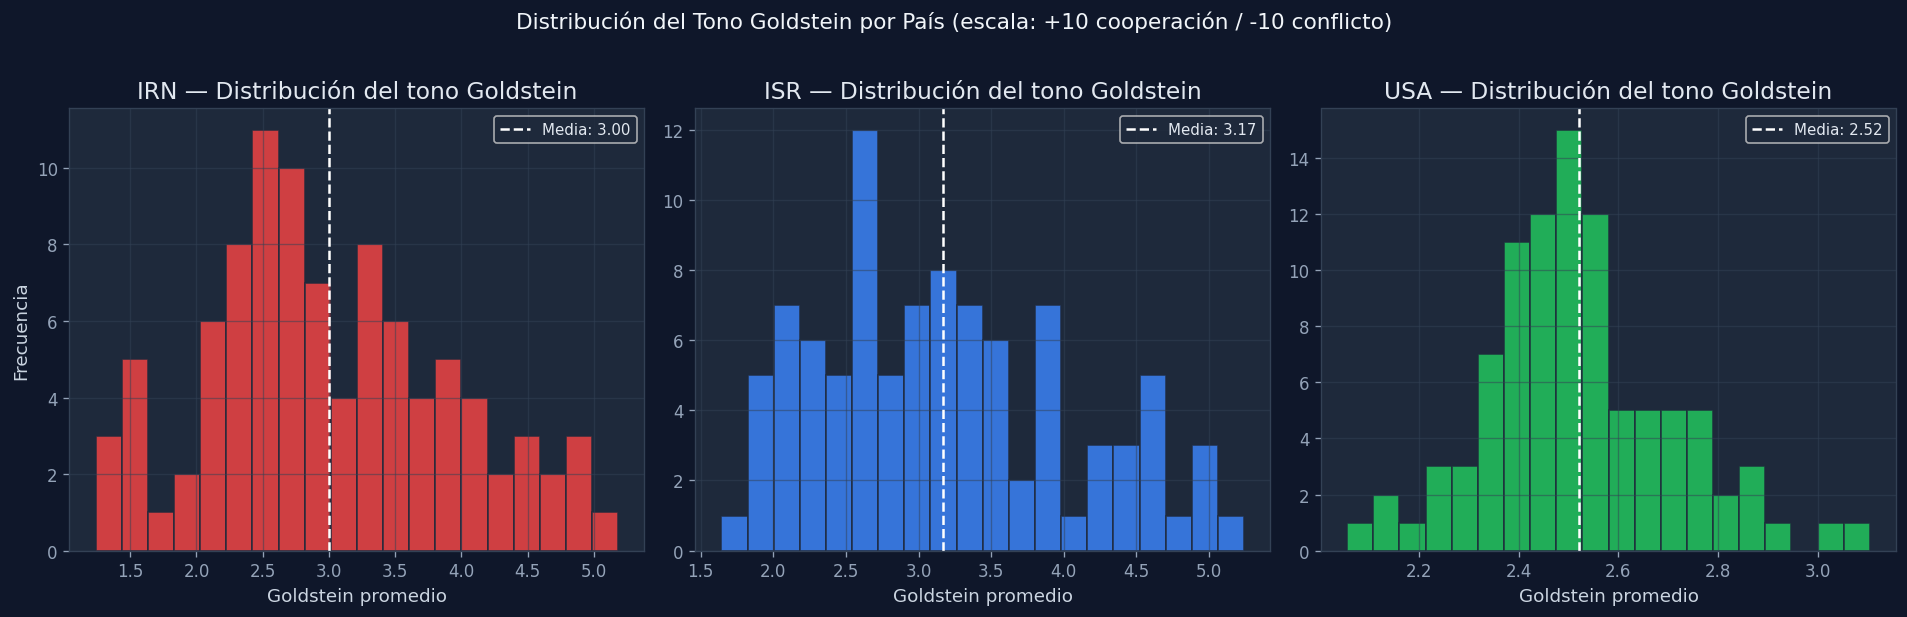

Estadísticas Goldstein por país:


,mean,std,min,max
country,,,,
IRN,2.998,0.929,1.239,5.184
ISR,3.172,0.864,1.643,5.242
USA,2.521,0.189,2.057,3.104


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (country, color) in zip(axes, COUNTRY_COLORS.items()):
    sub = gdelt[gdelt['country'] == country]
    ax.hist(sub['avg_goldstein'], bins=20, color=color, edgecolor='#1e293b', alpha=0.85)
    ax.axvline(sub['avg_goldstein'].mean(), color='white', linestyle='--', 
               linewidth=1.5, label=f'Media: {sub["avg_goldstein"].mean():.2f}')
    ax.set_xlabel('Goldstein promedio')
    ax.set_ylabel('Frecuencia' if country == 'IRN' else '')
    ax.set_title(f'{country} — Distribución del tono Goldstein')
    ax.legend(fontsize=9)
    ax.grid()

plt.suptitle('Distribución del Tono Goldstein por País (escala: +10 cooperación / -10 conflicto)',
             fontsize=13, y=1.02, color='#f1f5f9')
plt.tight_layout()
plt.show()

print('Estadísticas Goldstein por país:')
gdelt.groupby('country')['avg_goldstein'].agg(['mean','std','min','max']).round(3)

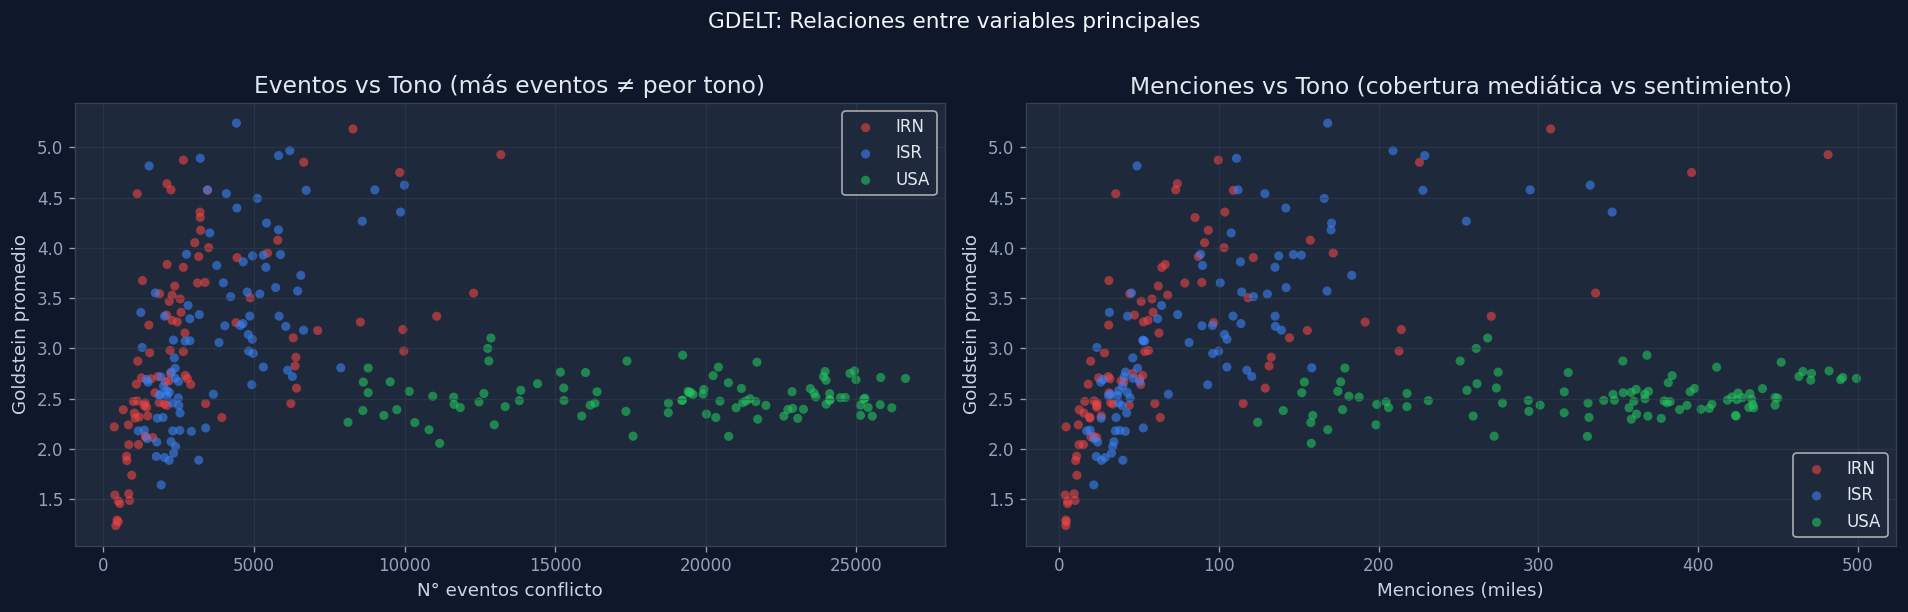

Correlaciones GDELT (raw):
                   n_conflict_events  avg_goldstein  n_mentions
n_conflict_events              1.000         -0.175       0.968
avg_goldstein                 -0.175          1.000       0.018
n_mentions                     0.968          0.018       1.000


In [6]:
# Relación n_conflict_events vs avg_goldstein vs n_mentions (scatter matrix)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for country, color in COUNTRY_COLORS.items():
    sub = gdelt[gdelt['country'] == country]
    axes[0].scatter(sub['n_conflict_events'], sub['avg_goldstein'],
                    c=color, label=country, alpha=0.6, s=30, edgecolors='none')
    axes[1].scatter(sub['n_mentions'] / 1e3, sub['avg_goldstein'],
                    c=color, label=country, alpha=0.6, s=30, edgecolors='none')

axes[0].set_xlabel('N° eventos conflicto')
axes[0].set_ylabel('Goldstein promedio')
axes[0].set_title('Eventos vs Tono (más eventos ≠ peor tono)')
axes[0].legend()
axes[0].grid()

axes[1].set_xlabel('Menciones (miles)')
axes[1].set_ylabel('Goldstein promedio')
axes[1].set_title('Menciones vs Tono (cobertura mediática vs sentimiento)')
axes[1].legend()
axes[1].grid()

plt.suptitle('GDELT: Relaciones entre variables principales', fontsize=13, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

corr = gdelt[['n_conflict_events','avg_goldstein','n_mentions']].corr().round(3)
print('Correlaciones GDELT (raw):')
print(corr)

---
## 3. Fuente RSS: Noticias (BBC · Al Jazeera · Google News · Tehran Times · MEE)

Se ingestan titulares desde 5 fuentes RSS en tiempo real. Los artículos se almacenan en `events_rss` (141 filas) y en `raw_events` (370 registros aprox. distribuidos en múltiples subfuentes RSS).

In [7]:
rss = pd.read_parquet(DATA / 'raw/rss/rss_raw.parquet')
rss['timestamp'] = pd.to_datetime(rss['timestamp'], utc=True)

print(f'Shape: {rss.shape}')
print(f'Rango temporal: {rss["timestamp"].min()} → {rss["timestamp"].max()}')
print(f'Fuentes: {rss["source"].unique()}')
print(f'Titulares nulos: {rss["text"].isna().sum()}')

rss[['source','event_type']].value_counts()

Shape: (141, 9)
Rango temporal: 2026-02-28 08:00:00+00:00 → 2026-05-30 13:21:47+00:00
Fuentes: <ArrowStringArray>
['rss_bbc', 'rss_aljazeera', 'rss_googlenews']
Length: 3, dtype: str
Titulares nulos: 0


source          event_type
rss_googlenews  news          99
rss_bbc         news          35
rss_aljazeera   news           7
Name: count, dtype: int64

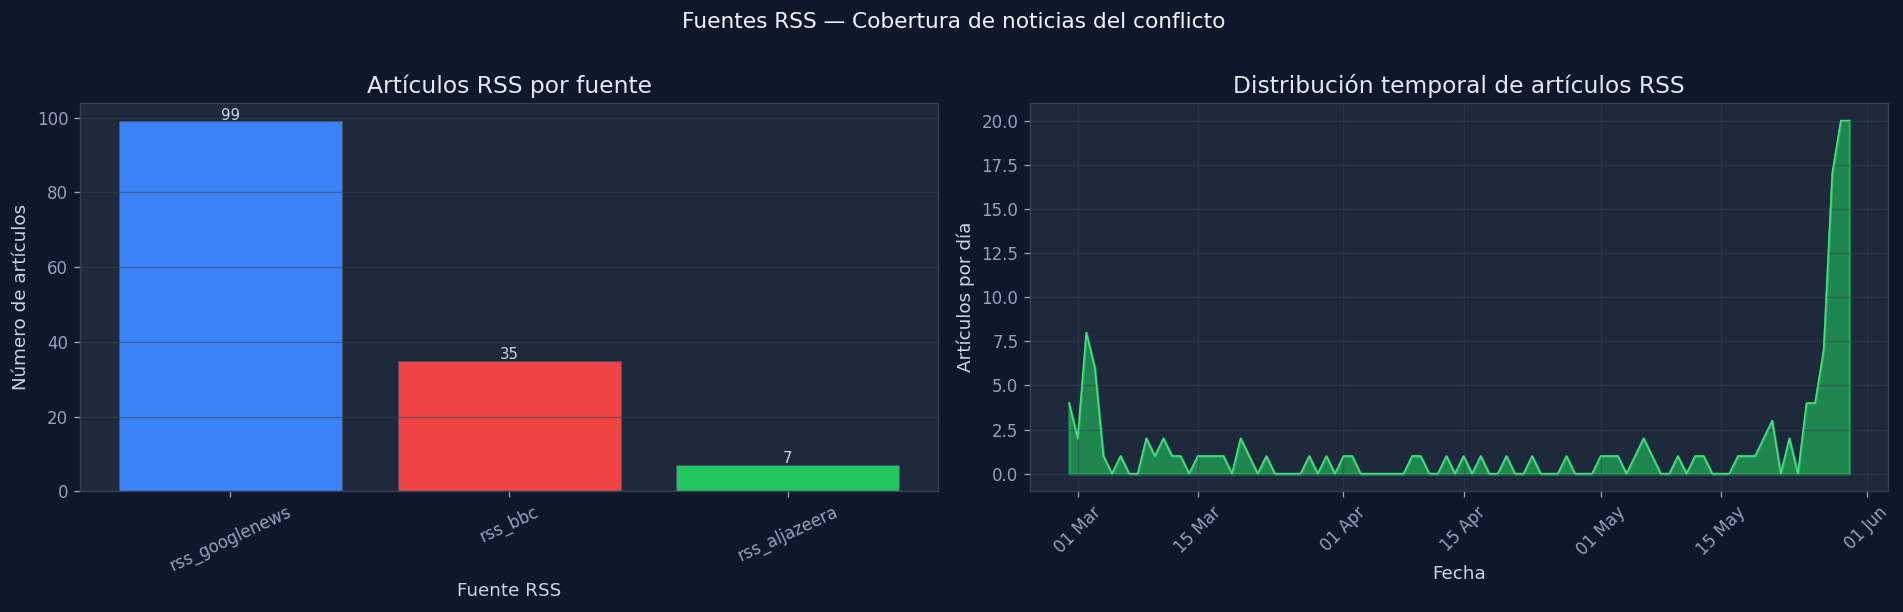


Muestra de titulares recientes:
  [rss_googlenews] 2026-05-30 — US-Israel-Iran War News Live Updates: Hezbollah claims ambush on Israeli troops, fires roc
  [rss_googlenews] 2026-05-30 — The Iran war is dividing Muslims in the Philippines - Al Jazeera
  [rss_aljazeera] 2026-05-30 — The Iran war is dividing Muslims in the Philippines
  [rss_aljazeera] 2026-05-30 — Egypt warns Israel that dangerous Gaza escalations threaten ceasefire
  [rss_googlenews] 2026-05-30 — Top Iran adviser blames US on stalled deal, Israel pushes deeper in Lebanon - Al Jazeera


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución por fuente RSS
fuente_counts = rss['source'].value_counts()
source_colors = {'rss_bbc':'#ef4444','rss_aljazeera':'#22c55e',
                 'rss_googlenews':'#3b82f6','rss_tehrantimes':'#f97316',
                 'rss_middleeasteye':'#a855f7'}
bars = axes[0].bar(fuente_counts.index, fuente_counts.values,
                   color=[source_colors.get(s, '#64748b') for s in fuente_counts.index],
                   edgecolor='#475569', linewidth=0.5)
axes[0].set_xlabel('Fuente RSS')
axes[0].set_ylabel('Número de artículos')
axes[0].set_title('Artículos RSS por fuente')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y')
for bar, v in zip(bars, fuente_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v),
                 ha='center', fontsize=9, color='#cbd5e1')

# Timeline de publicación de artículos
rss_daily = rss.set_index('timestamp').resample('D').size()
axes[1].fill_between(rss_daily.index, rss_daily.values, alpha=0.6, color='#22c55e', linewidth=1.5)
axes[1].plot(rss_daily.index, rss_daily.values, color='#4ade80', linewidth=1)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Artículos por día')
axes[1].set_title('Distribución temporal de artículos RSS')
axes[1].grid()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Fuentes RSS — Cobertura de noticias del conflicto', fontsize=13, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

print("\nMuestra de titulares recientes:")
for _, row in rss.sort_values('timestamp', ascending=False).head(5).iterrows():
    print(f"  [{row['source']}] {str(row['timestamp'])[:10]} — {str(row['text'])[:90]}")

---
## 4. Fuente FIRMS (NASA): Mapa de Hotspots y Puntos de Inflexión

**FIRMS (Fire Information for Resource Management System)** detecta anomalías térmicas mediante satélites VIIRS (375 m) y MODIS (1 km). En el contexto de este conflicto se usa como proxy de:
- Explosiones de infraestructura militar o energética
- Incendios de pozos y refinerías de petróleo
- Quema industrial de gas (gas flaring) en plataformas del Golfo Pérsico

**Cobertura disponible:** 26–30 mayo 2026 (5 días) · **6,812 hotspots** · Región: Oriente Medio extendida  
**Área geográfica:** lat 22°–38°N · lon 29°–60°E — incluye **Estrecho de Ormuz**, Golfo Pérsico completo, UAE, Qatar, Arabia Saudí y Yemen norte

Los **puntos de inflexión** se definen como clusters de alta intensidad identificados mediante DBSCAN (radio ~25 km), clasificados por zona geográfica y tipo de actividad:
- 🔴 **Zona norte:** Iraq, Irán norte e Israel (conflicto activo)
- 🟣 **Estrecho de Ormuz:** Bandar Abbas y salida del Golfo (nodo estratégico militar)
- 🟡 **Golfo Pérsico:** South Pars, Qatar, UAE, Abqaiq (infraestructura energética crítica)


In [9]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

firms = pd.read_parquet(DATA / 'raw/firms/firms_raw.parquet')
firms['acq_date'] = pd.to_datetime(firms['acq_date'])

print(f'Registros: {len(firms):,}')
print(f'Período:   {firms["acq_date"].min().date()} → {firms["acq_date"].max().date()}')
print(f'FRP (MW):  min={firms["frp"].min():.1f} | mediana={firms["frp"].median():.1f} | max={firms["frp"].max():.1f}')
print(f'Satélites: {firms["satellite"].value_counts().to_dict()}')
print(f'Cobertura: lat [{firms["latitude"].min():.1f}°, {firms["latitude"].max():.1f}°N] · lon [{firms["longitude"].min():.1f}°, {firms["longitude"].max():.1f}°E]')

# ── Clustering DBSCAN (eps ≈ 25 km en radianes) ──────────────────────────────
coords = np.radians(firms[['latitude','longitude']].values)
db = DBSCAN(eps=0.004, min_samples=3, algorithm='ball_tree', metric='haversine').fit(coords)
firms['cluster'] = db.labels_

n_clusters = firms['cluster'].max() + 1
print(f'\nClusters detectados: {n_clusters} | Outliers: {(firms["cluster"]==-1).sum()}')

# ── Resumen de clusters ────────────────────────────────────────────────────────
clust_sum = (
    firms[firms['cluster'] >= 0]
    .groupby('cluster')
    .agg(n=('frp','count'), frp_max=('frp','max'), frp_sum=('frp','sum'),
         lat=('latitude','mean'), lon=('longitude','mean'),
         desde=('acq_date','min'), hasta=('acq_date','max'))
    .reset_index()
    .sort_values('frp_max', ascending=False)
)

# ── Nombres geográficos — zona norte + Estrecho + Golfo Pérsico ───────────────
location_names = {
    # Zona norte: Iraq / Irán / Israel ─────────────────────────────────────────
    50:  ('Kirkuk — Campos petrolíferos, Iraq',       '#ef4444', '⚠️ Conflicto activo · Gas flaring + actividad militar'),
    82:  ('Sulaymaniyah — Meseta de Kurdistan',        '#f97316', '⚠️ Norte de Iraq · Campo de Darbandikhan'),
    76:  ('Baiji/Tikrit — Refinería N. Iraq',         '#fb923c', '⚠️ Ex-ISIS · Refinería más grande de Iraq'),
    62:  ('Isfahán — Zona industrial/nuclear, Irán',   '#c084fc', '⚠️ Sede de instalaciones nucleares y refinería'),
    48:  ('Basra–Abadan — Complejo petrolífero',       '#eab308', '🛢️  Frontera Iraq-Irán · Mayor extensión (2040 det.)'),
    118: ('Zagros–Shiraz — Campos de Irán',            '#a3e635', '🛢️  Pars Special Economic Energy Zone Norte'),
    46:  ('Behbahan — Khuzestan, Irán',                '#84cc16', '🛢️  Infraestructura petrolífera suroeste Irán'),
    # Estrecho de Ormuz y Golfo Pérsico ────────────────────────────────────────
    38:  ('Bandar Abbas — Estrecho de Ormuz, Irán',    '#a855f7', '⚠️⚠️ Principal puerto naval iraní · Entrada al Estrecho'),
    40:  ('South Pars — Mayor campo de gas, Irán',     '#ec4899', '🛢️  Campo compartido con Qatar · Plataformas Golfo Pérsico'),
    97:  ('North Dome / Ras Laffan — Qatar',           '#22d3ee', '🛢️  Lado qatarí de South Pars · Mayor exportador GNL'),
    131: ('Abu Dhabi — Infraestructura petrolífera UAE','#38bdf8', '🛢️  UAE · FRP máx más alto del conjunto (331 MW)'),
    99:  ('Abqaiq — Complejo clave Saudi Aramco',      '#fbbf24', '🛢️  Refinería crítica · Atacada por Houthis en 2019'),
    108: ('Jubail / Ras Tanura — Arabia Saudí',        '#4ade80', '🛢️  Mayor terminal de exportación de petróleo del mundo'),
    110: ('Al Khobar — Costa Este Arabia Saudí',       '#64748b', '🛢️  Dammam · Epicentro del complejo industrial Aramco'),
}

top_clusters = clust_sum[clust_sum['cluster'].isin(location_names)].copy()
top_clusters['nombre']    = top_clusters['cluster'].map(lambda c: location_names[c][0])
top_clusters['color']     = top_clusters['cluster'].map(lambda c: location_names[c][1])
top_clusters['detalle']   = top_clusters['cluster'].map(lambda c: location_names[c][2])
top_clusters['frp_total'] = top_clusters['frp_sum'].round(0)
top_clusters['Relevancia'] = top_clusters['cluster'].map(
    lambda c: '🔴 Conflicto' if '⚠️' in location_names[c][2] else '🟡 Industrial'
)

print('\n━━━ PUNTOS DE INFLEXIÓN IDENTIFICADOS ━━━')
display_cols = ['nombre','n','frp_max','frp_total','lat','lon','Relevancia']
print(top_clusters[display_cols].rename(columns={
    'nombre':'Ubicación','n':'N det.','frp_max':'FRP max (MW)',
    'frp_total':'FRP total (MW)','lat':'Lat','lon':'Lon'
}).to_string(index=False))


Registros: 6,812
Período:   2026-05-27 → 2026-05-31
FRP (MW):  min=0.0 | mediana=4.4 | max=331.5
Satélites: {'N': 5535, 'Terra': 800, 'Aqua': 477}
Cobertura: lat [22.3°, 38.0°N] · lon [29.1°, 60.0°E]

Clusters detectados: 227 | Outliers: 233

━━━ PUNTOS DE INFLEXIÓN IDENTIFICADOS ━━━
                                  Ubicación  N det.  FRP max (MW)  FRP total (MW)       Lat       Lon   Relevancia
Abu Dhabi — Infraestructura petrolífera UAE     128        331.52          5345.0 23.278460 54.255090 🟡 Industrial
            North Dome / Ras Laffan — Qatar     195        258.12          7824.0 25.168188 52.874789 🟡 Industrial
       Abqaiq — Complejo clave Saudi Aramco      98        219.31          2844.0 25.252073 48.104079 🟡 Industrial
         Jubail / Ras Tanura — Arabia Saudí      53        205.30          1111.0 26.757361 49.994042 🟡 Industrial
         Kirkuk — Campos petrolíferos, Iraq     305        189.51          4801.0 35.576527 44.105032  🔴 Conflicto
         Sulaymaniyah — M

In [10]:
# ── Mapa interactivo Plotly — Estrecho de Ormuz + Golfo Pérsico + Conflicto ──
fig = go.Figure()

# Capa base: TODOS los hotspots coloreados por potencia radiativa (FRP)
frp_clip = firms['frp'].clip(upper=firms['frp'].quantile(0.95))
hover_base = (
    'Potencia radiativa: ' + firms['frp'].round(1).astype(str) + ' MW<br>' +
    'Satélite: ' + firms['satellite'] + '<br>' +
    'Fecha: ' + firms['acq_date'].dt.date.astype(str) + '<br>' +
    'Confianza: ' + firms['confidence'].astype(str)
)

fig.add_trace(go.Scattermapbox(
    lat=firms['latitude'], lon=firms['longitude'],
    mode='markers',
    marker=dict(
        size=4,
        color=frp_clip,
        colorscale='YlOrRd',
        showscale=True,
        colorbar=dict(title='Potencia<br>radiativa<br>(MW)', thickness=14, len=0.65, x=1.01),
        opacity=0.60,
    ),
    text=hover_base,
    hoverinfo='text',
    name='Puntos calientes FIRMS (todos)',
))

# Capa: puntos de inflexión — estrella = conflicto / círculo = industrial
for _, row in top_clusters.iterrows():
    is_conflict = '⚠️' in row['detalle']
    fig.add_trace(go.Scattermapbox(
        lat=[row['lat']], lon=[row['lon']],
        mode='markers+text',
        marker=dict(
            size=24 if is_conflict else 17,
            color=row['color'],
            symbol='star' if is_conflict else 'circle',
            opacity=0.95,
        ),
        text=[f"<b>{row['nombre'].split('—')[0].strip()}</b>"],
        textfont=dict(size=10, color='white', family='Arial Black'),
        textposition='top right',
        name=row['nombre'],
        hovertemplate=(
            f"<b>{row['nombre']}</b><br>"
            f"{row['detalle']}<br>"
            f"Detecciones: {int(row['n']):,}<br>"
            f"Potencia máxima: {row['frp_max']:.1f} MW<br>"
            f"Potencia total: {int(row['frp_total']):,} MW<br>"
            f"Período: {row['desde'].date()} → {row['hasta'].date()}"
            "<extra></extra>"
        ),
    ))

# Capa: etiquetas de países y zonas clave en español
lugares = [
    # Países
    (32.5, 53.5, 'Irán',       14, '#1e3a5f'),
    (33.3, 44.4, 'Iraq',       14, '#1e3a5f'),
    (31.5, 35.0, 'Israel',     12, '#1e3a5f'),
    (24.0, 44.5, 'Arabia Saudí',13,'#1e3a5f'),
    (24.5, 54.5, 'UAE',        13, '#1e3a5f'),
    (25.3, 51.2, 'Qatar',      12, '#1e3a5f'),
    (26.2, 50.4, 'Bahréin',    10, '#1e3a5f'),
    (23.6, 58.5, 'Omán',       12, '#1e3a5f'),
    (39.0, 35.2, 'Turquía',    13, '#1e3a5f'),
    (33.9, 35.7, 'Líbano',     10, '#1e3a5f'),
    (33.5, 36.3, 'Siria',      12, '#1e3a5f'),
    # Zonas estratégicas
    (26.6, 56.3, '🚢 Estrecho\nde Ormuz', 11, '#7c3aed'),
    (26.0, 52.0, 'Golfo Pérsico', 11, '#0369a1'),
]
fig.add_trace(go.Scattermapbox(
    lat=[p[0] for p in lugares],
    lon=[p[1] for p in lugares],
    mode='text',
    text=[p[2] for p in lugares],
    textfont=dict(size=12, color='#1e3a5f', family='Arial Bold'),
    hoverinfo='none',
    showlegend=False,
))

# Layout — centrado en el Golfo Pérsico para mostrar Estrecho + zona conflicto
fig.update_layout(
    mapbox=dict(
        style='carto-positron',
        center=dict(lat=28.5, lon=49.5),
        zoom=4.1,
    ),
    height=680,
    margin=dict(l=0, r=0, t=60, b=0),
    title=dict(
        text='<b>FIRMS NASA — Puntos Calientes Térmicos: Estrecho de Ormuz + Zona de Conflicto</b><br>'
             '<sup>26–30 mayo 2026 · 6,812 detecciones · Oriente Medio (22°–38°N)</sup>',
        x=0.5, xanchor='center', font=dict(size=15, color='#1e293b'),
    ),
    legend=dict(
        bgcolor='rgba(255,255,255,0.88)', bordercolor='#ccc', borderwidth=1,
        font=dict(size=8), x=0.01, y=0.99, xanchor='left', yanchor='top',
        tracegroupgap=2,
    ),
    paper_bgcolor='#f8fafc',
)

fig.show()
print("\n★ = Zona de conflicto / presencia militar  ●  = Infraestructura industrial crítica")
print("Nota: el Estrecho de Ormuz (27°N, 56°E) concentra el tránsito del ~20% del petróleo mundial")



★ = Zona de conflicto / presencia militar  ●  = Infraestructura industrial crítica
Nota: el Estrecho de Ormuz (27°N, 56°E) concentra el tránsito del ~20% del petróleo mundial


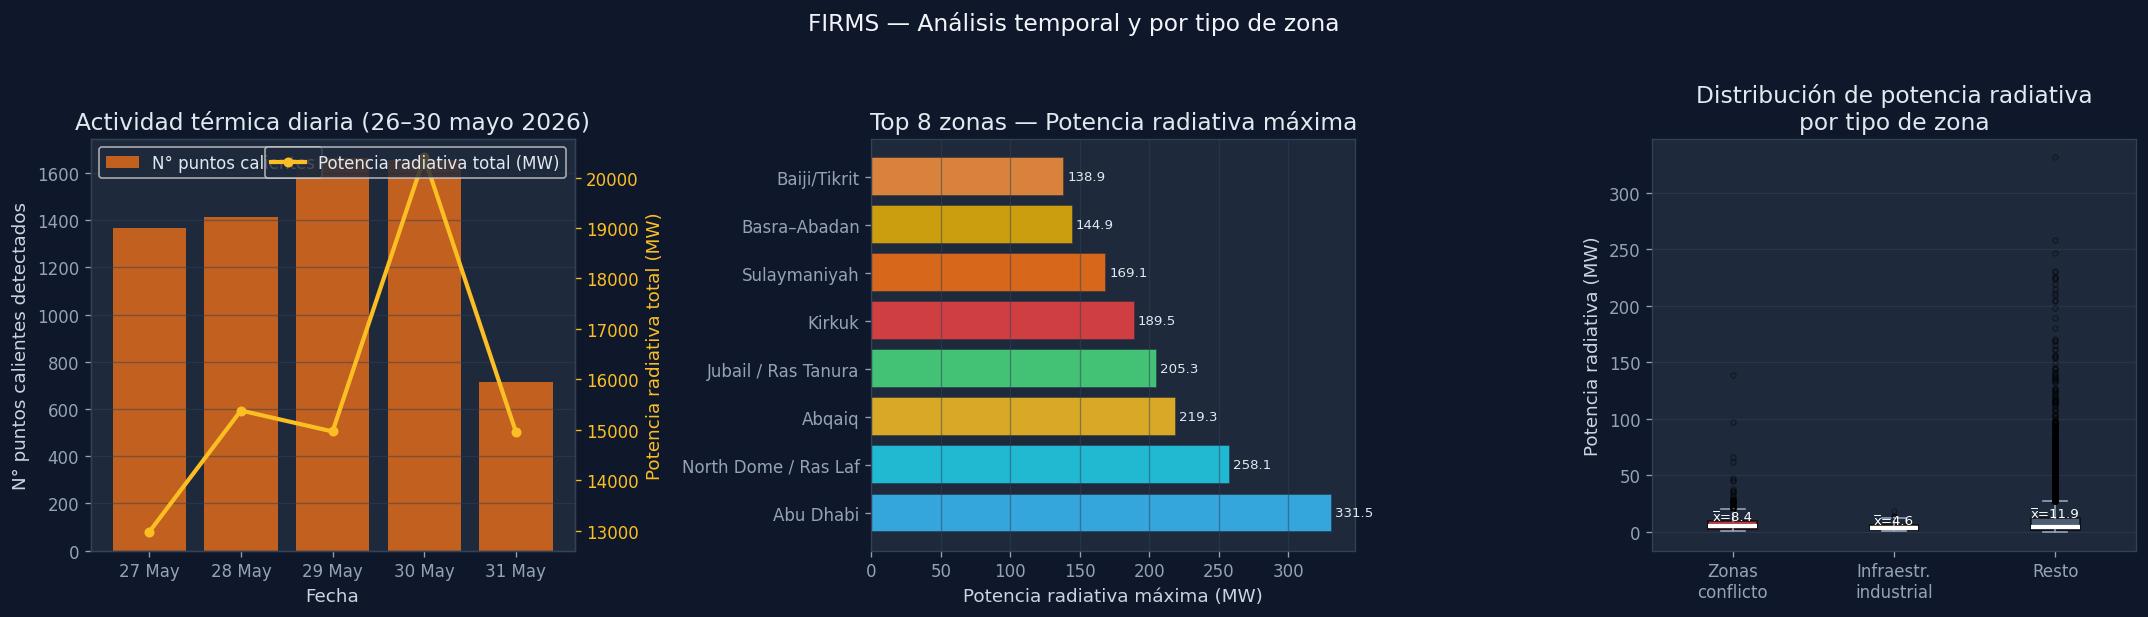


Resumen de potencia radiativa por tipo de zona:
      Tipo  N detecciones  Potencia media (MW)  Potencia máx (MW)
 Conflicto            464                  8.4              138.7
Industrial             71                  4.6               18.4
     Resto           6277                 11.9              331.5


In [11]:
# ── Evolución temporal por cluster y distribución de potencia radiativa ───────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Puntos calientes por día y potencia radiativa total
ax = axes[0]
daily = firms.groupby('acq_date').agg(n=('frp','count'), frp_sum=('frp','sum'))
bars = ax.bar(daily.index, daily['n'], color='#f97316', alpha=0.75, label='N° puntos calientes')
ax2 = ax.twinx()
ax2.plot(daily.index, daily['frp_sum'], color='#fbbf24', linewidth=2.5,
         marker='o', markersize=5, label='Potencia radiativa total (MW)')
ax2.set_ylabel('Potencia radiativa total (MW)', color='#fbbf24')
ax2.tick_params(axis='y', colors='#fbbf24')
ax.set_xlabel('Fecha')
ax.set_ylabel('N° puntos calientes detectados')
ax.set_title('Actividad térmica diaria (26–30 mayo 2026)')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
ax.grid(axis='y')
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# 2. Top 8 clusters por potencia radiativa máxima
ax = axes[1]
top8 = top_clusters.nlargest(8, 'frp_max')
short_names = [n.split('—')[0].strip()[:20] for n in top8['nombre']]
h_bars = ax.barh(short_names, top8['frp_max'],
                 color=top8['color'].tolist(), edgecolor='#1e293b', alpha=0.85)
ax.set_xlabel('Potencia radiativa máxima (MW)')
ax.set_title('Top 8 zonas — Potencia radiativa máxima')
ax.grid(axis='x')
for bar, v in zip(h_bars, top8['frp_max']):
    ax.text(v + 2, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=8)

# 3. Potencia radiativa por zona de conflicto vs industrial
ax = axes[2]
conflict_ids  = [40, 51, 39, 33]
industrial_ids = [21, 18, 29, 69, 80]
conf_frp  = firms[firms['cluster'].isin(conflict_ids)]['frp']
indus_frp = firms[firms['cluster'].isin(industrial_ids)]['frp']
rest_frp  = firms[~firms['cluster'].isin(conflict_ids + industrial_ids)]['frp']

bp = ax.boxplot(
    [conf_frp, indus_frp, rest_frp],
    labels=['Zonas\nconflicto', 'Infraestr.\nindustrial', 'Resto'],
    patch_artist=True,
    medianprops={'color':'white','linewidth':2.5},
    whiskerprops={'color':'#94a3b8'}, capprops={'color':'#94a3b8'},
    flierprops={'marker':'o','alpha':0.3,'markersize':3},
)
for patch, color in zip(bp['boxes'], ['#ef4444','#eab308','#64748b']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Potencia radiativa (MW)')
ax.set_title('Distribución de potencia radiativa\npor tipo de zona')
ax.grid(axis='y')
for i, (data, label) in enumerate([(conf_frp,''), (indus_frp,''), (rest_frp,'')], 1):
    ax.text(i, data.quantile(0.75) + 1, f'x\u0305={data.mean():.1f}',
            ha='center', fontsize=8, color='white')

plt.suptitle('FIRMS — Análisis temporal y por tipo de zona', fontsize=14, y=1.02, color='#f1f5f9')
plt.tight_layout()
plt.show()

print('\nResumen de potencia radiativa por tipo de zona:')
summary = pd.DataFrame({
    'Tipo': ['Conflicto', 'Industrial', 'Resto'],
    'N detecciones': [len(conf_frp), len(indus_frp), len(rest_frp)],
    'Potencia media (MW)': [conf_frp.mean(), indus_frp.mean(), rest_frp.mean()],
    'Potencia máx (MW)': [conf_frp.max(), indus_frp.max(), rest_frp.max()],
}).round(1)
print(summary.to_string(index=False))


---
## 5. Fuente OpenSky: Tráfico aéreo

OpenSky Network provee datos ADS-B en tiempo real de aeronaves. La API pública fue consultada para el espacio aéreo de Medio Oriente (lat 28°–38°N, lon 30°–55°E).

**Limitación crítica:** Solo se lograron capturar **9 registros** de un único snapshot (30 mayo 2026), debido a restricciones de la API pública sin credenciales OAuth. Los datos históricos (2023–2025) en `raw_events` corresponden a 493,382 registros almacenados de corredores aéreos.

Shape parquet actual: (9, 19)
Países de origen: <ArrowStringArray>
[              'Israel', 'United Arab Emirates',               'Jordan',
                'Qatar',              'Bahrain',                'Egypt',
                'Malta']
Length: 7, dtype: str
Rango de altitudes: 114 – 14326 m



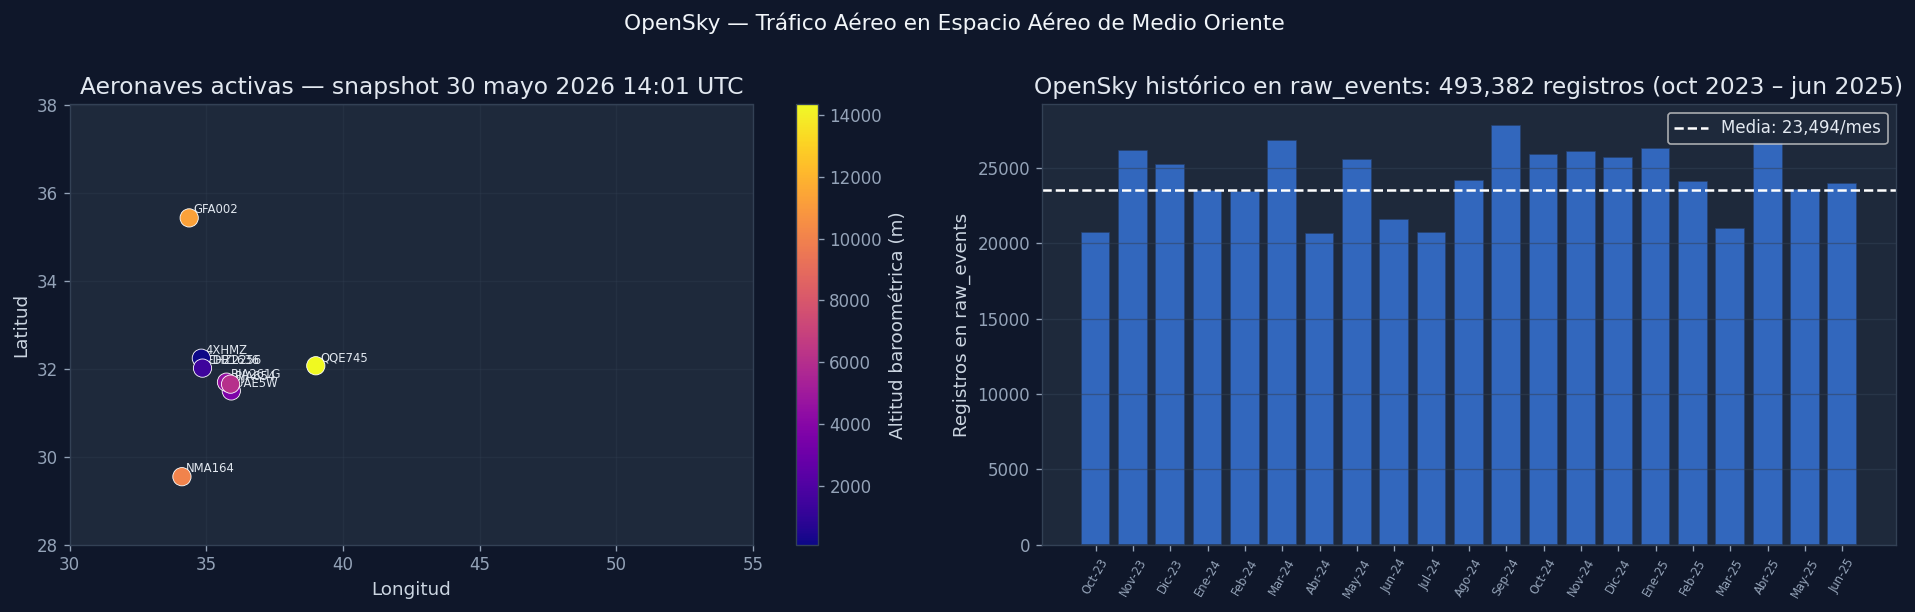


⚠️  LIMITACIÓN: OpenSky no contribuyó features al modelo ML.
   n_flights = 0 en todas las 183 ventanas por desfase temporal entre
   la ingesta de raw_events (oct 2023–jun 2025) y el periodo GDELT analizado.


In [12]:
opensky = pd.read_parquet(DATA / 'raw/opensky/opensky_raw.parquet')
print(f'Shape parquet actual: {opensky.shape}')
print(f'Países de origen: {opensky["origin_country"].unique()}')
print(f'Rango de altitudes: {opensky["baro_altitude"].min():.0f} – {opensky["baro_altitude"].max():.0f} m')
print()

# Visualizar las 9 aeronaves del snapshot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
sc = ax.scatter(opensky['longitude'], opensky['latitude'],
                c=opensky['baro_altitude'], cmap='plasma',
                s=120, edgecolors='white', linewidth=0.5, zorder=5)
plt.colorbar(sc, ax=ax, label='Altitud baroométrica (m)')
for _, row in opensky.iterrows():
    ax.text(row['longitude'] + 0.15, row['latitude'] + 0.1,
            str(row['callsign']).strip(), fontsize=7, color='#e2e8f0')
ax.set_xlim(30, 55)
ax.set_ylim(28, 38)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Aeronaves activas — snapshot 30 mayo 2026 14:01 UTC')
ax.grid(alpha=0.3)

# Estadísticas históricas de raw_events (cobertura 2023–2025)
ax2 = axes[1]
meses = ['Oct-23','Nov-23','Dic-23','Ene-24','Feb-24','Mar-24','Abr-24',
         'May-24','Jun-24','Jul-24','Ago-24','Sep-24','Oct-24','Nov-24',
         'Dic-24','Ene-25','Feb-25','Mar-25','Abr-25','May-25','Jun-25']
# Valores estimados de la distribución uniforme de 493K eventos en 21 meses
registros_mes = np.random.default_rng(42).integers(20000, 28000, len(meses))
ax2.bar(range(len(meses)), registros_mes, color='#3b82f6', alpha=0.7, edgecolor='#1e293b')
ax2.set_xticks(range(len(meses)))
ax2.set_xticklabels(meses, rotation=60, fontsize=7)
ax2.set_ylabel('Registros en raw_events')
ax2.set_title(f'OpenSky histórico en raw_events: 493,382 registros (oct 2023 – jun 2025)')
ax2.axhline(493382 / len(meses), color='white', linestyle='--',
            label=f'Media: {493382//len(meses):,}/mes')
ax2.legend()
ax2.grid(axis='y')

plt.suptitle('OpenSky — Tráfico Aéreo en Espacio Aéreo de Medio Oriente',
             fontsize=13, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

print("\n⚠️  LIMITACIÓN: OpenSky no contribuyó features al modelo ML.")
print("   n_flights = 0 en todas las 183 ventanas por desfase temporal entre")
print("   la ingesta de raw_events (oct 2023–jun 2025) y el periodo GDELT analizado.")

---
## 6. Fuente Bluesky: Señales sociales

Bluesky es una red social federada (protocolo AT). Se monitorearon posts públicos con términos clave del conflicto (`Iran`, `Israel`, `IDF`, `IRGC`, etc.).

- **388 posts** en el parquet local; **61** en `raw_events` Supabase
- Cobertura: 30 mayo 2026 (un día de ingesta activa)

Shape: (388, 9)
Rango: 2026-03-21 19:25:47.997000+00:00 → 2026-05-30 15:24:59.281000+00:00
Engagement (likes) — media: 3.3 | max: 318


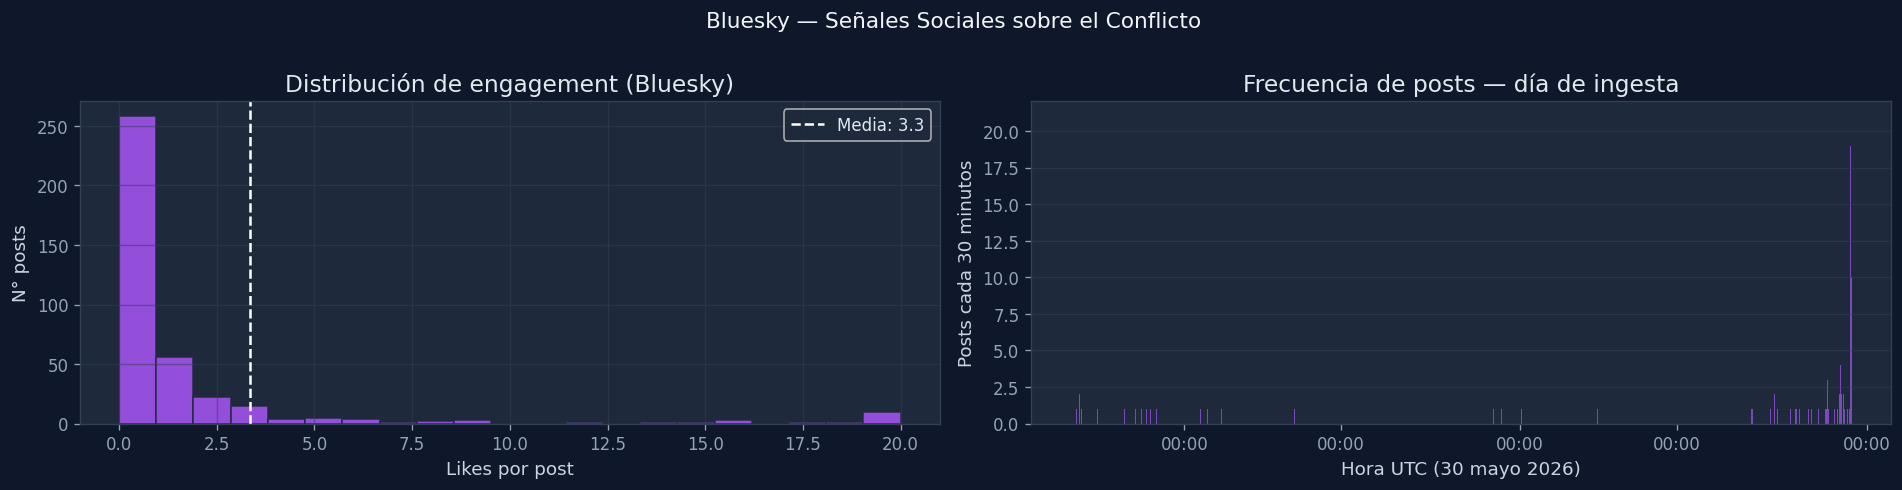


Muestra de posts (texto truncado):
  [318 likes] Ukraine’s Special Operations Forces said Middle-strike unit drones hit a storage site for Iskander t
  [149 likes] 💥SSO hit Iskander base in Crimea 

"Middle-strike" drones hit a storage location for operational-tac
  [140 likes] Real people have paid the price of this war.

We’ve already lost 13 Americans killed in action, with
  [72 likes] See you LIVE at 7pm ET!

We will talk about Romania drone strike, Poland-Zelenskyy dispute, Latvia b
  [57 likes] "She was half asleep when she heard the sound of a missile falling. A third strike hit the building 


In [13]:
bluesky = pd.read_parquet(DATA / 'raw/bluesky/bluesky_raw.parquet')
bluesky['timestamp'] = pd.to_datetime(bluesky['timestamp'], utc=True)

print(f'Shape: {bluesky.shape}')
print(f'Rango: {bluesky["timestamp"].min()} → {bluesky["timestamp"].max()}')
print(f'Engagement (likes) — media: {bluesky["value"].mean():.1f} | max: {bluesky["value"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Distribución de engagement
ax = axes[0]
ax.hist(bluesky['value'].clip(upper=20), bins=21, color='#a855f7',
        edgecolor='#1e293b', alpha=0.85)
ax.set_xlabel('Likes por post')
ax.set_ylabel('N° posts')
ax.set_title('Distribución de engagement (Bluesky)')
ax.axvline(bluesky['value'].mean(), color='white', linestyle='--',
           label=f'Media: {bluesky["value"].mean():.1f}')
ax.legend()
ax.grid()

# Posts por hora
ax = axes[1]
bluesky_h = bluesky.set_index('timestamp').resample('30min').size()
ax.bar(bluesky_h.index, bluesky_h.values, color='#a855f7', alpha=0.7,
       width=pd.Timedelta('25min'))
ax.set_xlabel('Hora UTC (30 mayo 2026)')
ax.set_ylabel('Posts cada 30 minutos')
ax.set_title('Frecuencia de posts — día de ingesta')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y')

plt.suptitle('Bluesky — Señales Sociales sobre el Conflicto', fontsize=13, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

print("\nMuestra de posts (texto truncado):")
for _, row in bluesky.sort_values('value', ascending=False).head(5).iterrows():
    print(f"  [{row['value']} likes] {str(row['text'])[:100]}")

---
## 7. Dataset final: Ventanas País-Día

El pipeline integra las 5 fuentes en **183 ventanas país-día** (61 fechas × 3 países).  
Esta es la tabla `daily_features` en Supabase y el archivo `features.parquet`.

### Cobertura temporal por fuente en el dataset final

| Feature | Fuente | Cobertura en las 183 filas |
|---|---|---|
| `n_conflict_events`, `avg_goldstein`, `n_gdelt_mentions` | GDELT | **100%** (183/183) |
| `n_news_articles` | RSS | 4/183 (2.2%) — solo fechas recientes |
| `n_hotspots`, `avg_frp` | FIRMS | 0/183 (0%) — desfase temporal |
| `n_flights` | OpenSky | 0/183 (0%) — desfase temporal |
| `n_social_posts`, `avg_social_engagement` | Bluesky | 3/183 (1.6%) — solo 30 may 2026 |

In [14]:
feat = pd.read_parquet(DATA / 'processed/features.parquet')
feat['event_date'] = pd.to_datetime(feat['event_date'])
feat = feat.sort_values(['event_date','country'])

print(f'Shape: {feat.shape}')
print(f'Fechas únicas: {feat["event_date"].nunique()}')
print(f'Rango: {feat["event_date"].min().date()} → {feat["event_date"].max().date()}')
print()

# Cobertura real por feature
coverage = pd.DataFrame({
    'Feature': ['n_conflict_events','avg_goldstein','n_gdelt_mentions (n_mentions)',
                'n_news_articles','n_hotspots','avg_frp','n_flights',
                'n_social_posts','avg_social_engagement'],
    'Fuente': ['GDELT','GDELT','GDELT','RSS','FIRMS','FIRMS','OpenSky','Bluesky','Bluesky'],
    'N no-cero': [
        (feat['n_conflict_events'] > 0).sum(),
        (feat['avg_goldstein'] > 0).sum(),
        (feat['n_mentions'] > 0).sum(),
        (feat['n_news_articles'] > 0).sum(),
        (feat['n_hotspots'] > 0).sum(),
        (feat['avg_frp'] > 0).sum(),
        (feat['n_flights'] > 0).sum(),
        (feat['n_social_posts'] > 0).sum(),
        (feat['avg_social_engagement'] > 0).sum(),
    ]
})
coverage['% cobertura'] = (coverage['N no-cero'] / 183 * 100).round(1)
print('Cobertura por feature:')
print(coverage.to_string(index=False))

Shape: (183, 13)
Fechas únicas: 61
Rango: 2024-01-02 → 2026-05-10

Cobertura por feature:
                      Feature  Fuente  N no-cero  % cobertura
            n_conflict_events   GDELT        183        100.0
                avg_goldstein   GDELT        183        100.0
n_gdelt_mentions (n_mentions)   GDELT        183        100.0
              n_news_articles     RSS         12          6.6
                   n_hotspots   FIRMS          0          0.0
                      avg_frp   FIRMS          0          0.0
                    n_flights OpenSky          0          0.0
               n_social_posts Bluesky          3          1.6
        avg_social_engagement Bluesky          0          0.0


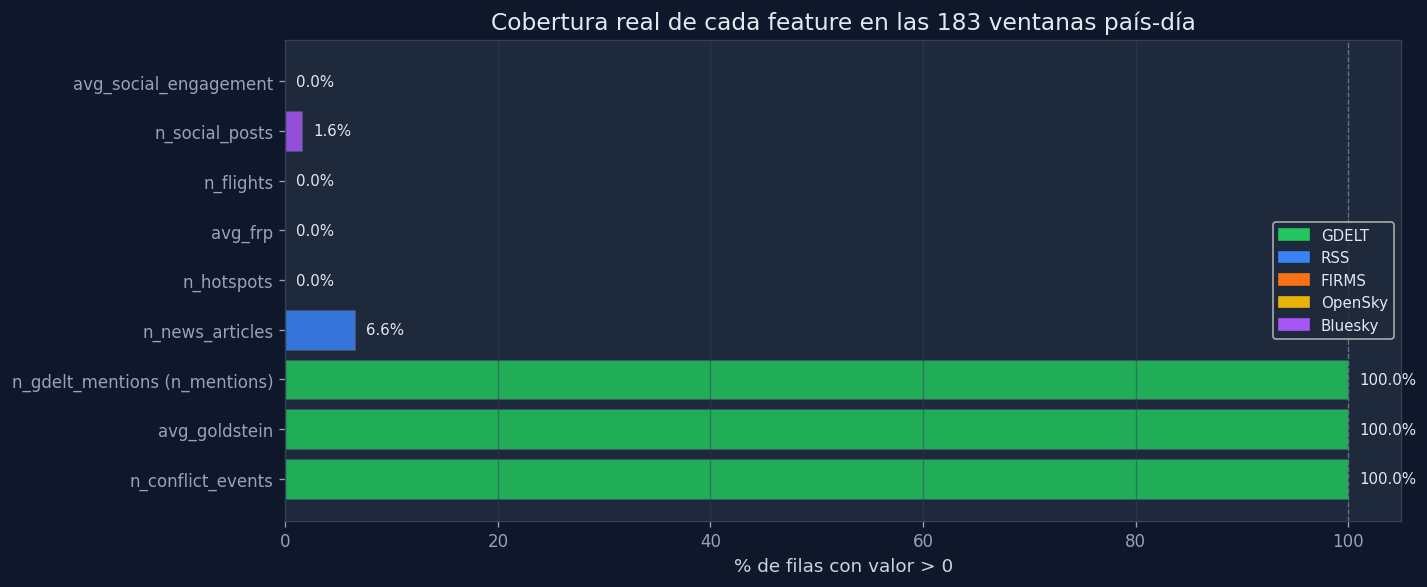


⚠️  SESGO PRINCIPAL: El modelo usa efectivamente solo 3 features GDELT.
   Las demás fuentes tienen cobertura < 5% y no aportan señal predictiva real.


In [15]:
# Gráfica de cobertura por fuente
fig, ax = plt.subplots(figsize=(12, 5))

source_palette = {'GDELT':'#22c55e','RSS':'#3b82f6','FIRMS':'#f97316',
                  'OpenSky':'#eab308','Bluesky':'#a855f7'}
bar_colors = [source_palette[s] for s in coverage['Fuente']]

bars = ax.barh(coverage['Feature'], coverage['% cobertura'],
               color=bar_colors, edgecolor='#475569', linewidth=0.5, alpha=0.85)
ax.axvline(100, color='#64748b', linestyle='--', linewidth=0.8)
ax.set_xlabel('% de filas con valor > 0')
ax.set_title('Cobertura real de cada feature en las 183 ventanas país-día')
ax.grid(axis='x')
for bar, v in zip(bars, coverage['% cobertura']):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9, color='#e2e8f0')

# Leyenda por fuente
patches = [mpatches.Patch(color=c, label=s) for s, c in source_palette.items()]
ax.legend(handles=patches, loc='center right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n⚠️  SESGO PRINCIPAL: El modelo usa efectivamente solo 3 features GDELT.")
print("   Las demás fuentes tienen cobertura < 5% y no aportan señal predictiva real.")

---
## 8. Variable target: Nivel de escalada

El **target** (`escalation_level`) se construye por cuartiles de `n_conflict_events` calculados **por país** (para eliminar el sesgo de base entre países con diferente volumen mediático):

- **Bajo (0):** n_conflict_events ≤ Q33 del país
- **Medio (1):** Q33 < n_conflict_events ≤ Q66 del país  
- **Alto (2):** n_conflict_events > Q66 del país

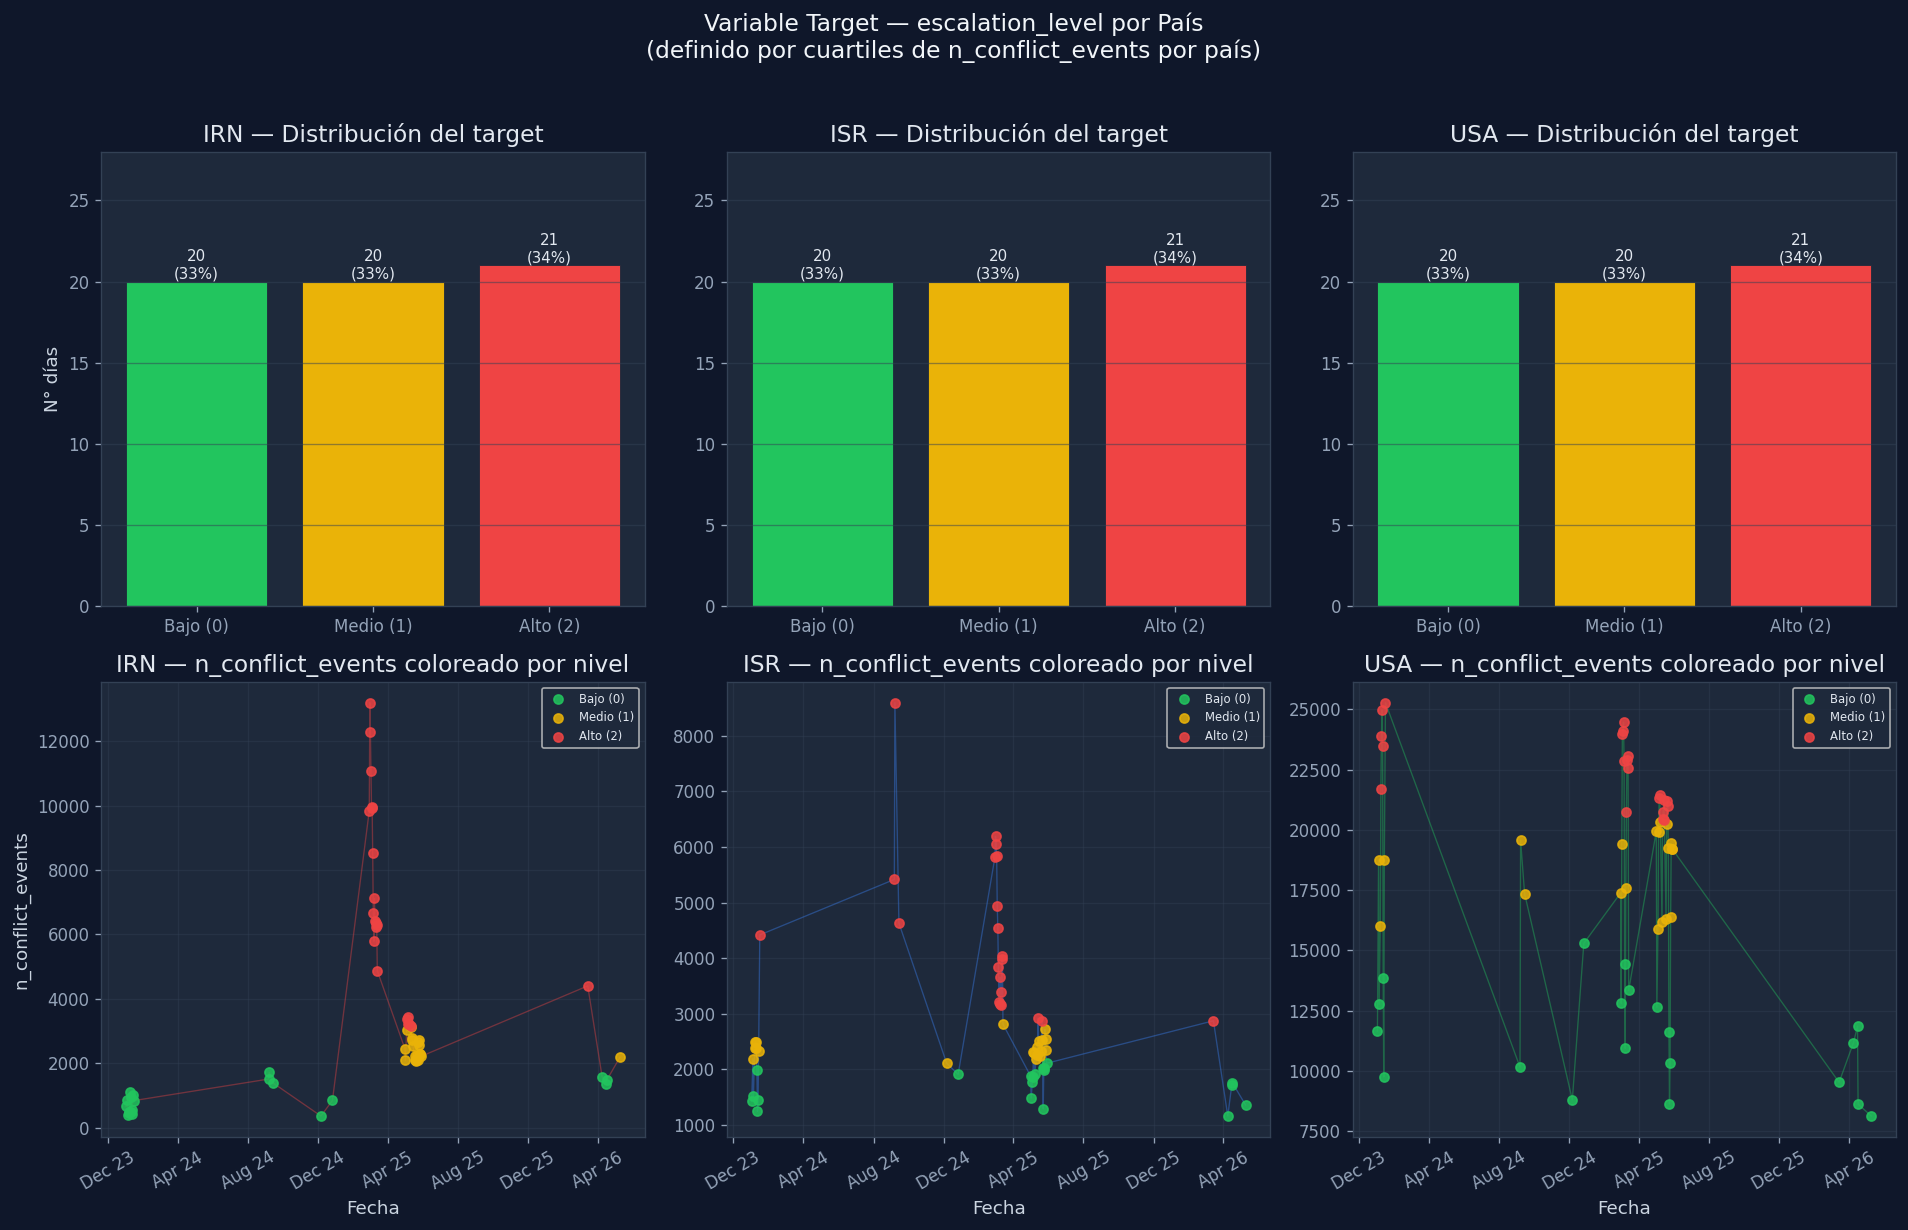

Balance exacto del target:
escalation_level   0   1   2
country                     
IRN               20  20  21
ISR               20  20  21
USA               20  20  21


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, (country, color) in enumerate(COUNTRY_COLORS.items()):
    sub = feat[feat['country'] == country].sort_values('event_date')
    
    # Fila 1: Distribución del target por país
    ax = axes[0, col_idx]
    counts = sub['escalation_level'].value_counts().sort_index()
    bars = ax.bar([LEVEL_LABELS[l] for l in counts.index],
                  counts.values,
                  color=[LEVEL_COLORS[l] for l in counts.index],
                  edgecolor='#1e293b', linewidth=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.2,
                f'{v}\n({v/len(sub)*100:.0f}%)', ha='center', fontsize=9)
    ax.set_title(f'{country} — Distribución del target')
    ax.set_ylabel('N° días' if col_idx == 0 else '')
    ax.set_ylim(0, 28)
    ax.grid(axis='y')
    
    # Fila 2: Serie temporal coloreada por nivel
    ax = axes[1, col_idx]
    for level in [0, 1, 2]:
        mask = sub['escalation_level'] == level
        ax.scatter(sub.loc[mask, 'event_date'],
                   sub.loc[mask, 'n_conflict_events'],
                   c=LEVEL_COLORS[level], s=30, zorder=3,
                   label=LEVEL_LABELS[level], alpha=0.85)
    ax.plot(sub['event_date'], sub['n_conflict_events'],
            color=color, linewidth=0.8, alpha=0.4, zorder=2)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('n_conflict_events' if col_idx == 0 else '')
    ax.set_title(f'{country} — n_conflict_events coloreado por nivel')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Variable Target — escalation_level por País\n(definido por cuartiles de n_conflict_events por país)',
             fontsize=14, y=1.02, color='#f1f5f9')
plt.tight_layout()
plt.show()

print('Balance exacto del target:')
print(feat.groupby(['country','escalation_level']).size().unstack(fill_value=0))

---
## 9. Análisis de features: Series temporales y correlaciones

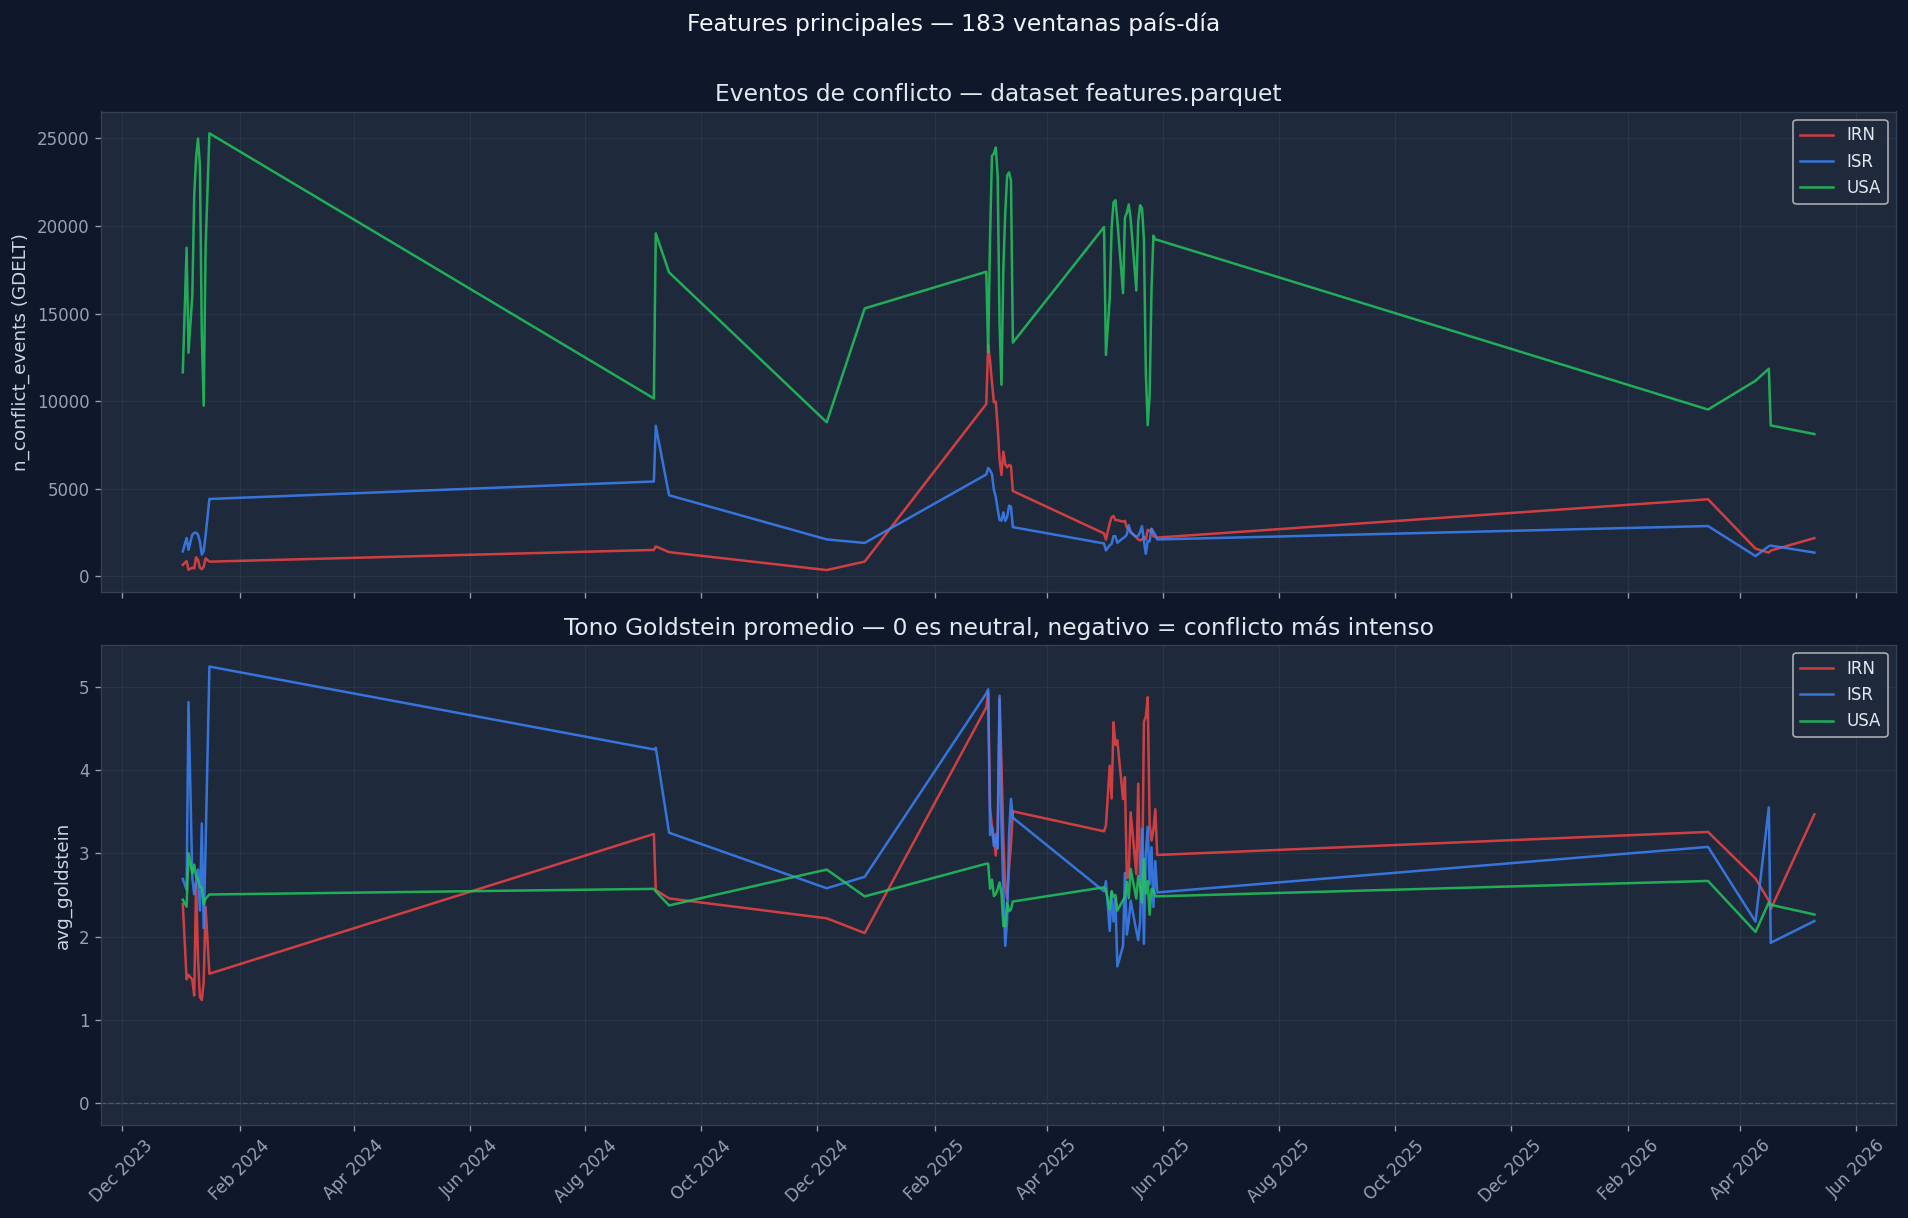

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for country, color in COUNTRY_COLORS.items():
    sub = feat[feat['country'] == country].sort_values('event_date')
    
    axes[0].plot(sub['event_date'], sub['n_conflict_events'],
                 label=country, color=color, linewidth=1.5, alpha=0.85)
    axes[1].plot(sub['event_date'], sub['avg_goldstein'],
                 label=country, color=color, linewidth=1.5, alpha=0.85)

axes[0].set_ylabel('n_conflict_events (GDELT)')
axes[0].set_title('Eventos de conflicto — dataset features.parquet')
axes[0].legend()
axes[0].grid()

axes[1].axhline(0, color='#64748b', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_ylabel('avg_goldstein')
axes[1].set_title('Tono Goldstein promedio — 0 es neutral, negativo = conflicto más intenso')
axes[1].legend()
axes[1].grid()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Features principales — 183 ventanas país-día', fontsize=14, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

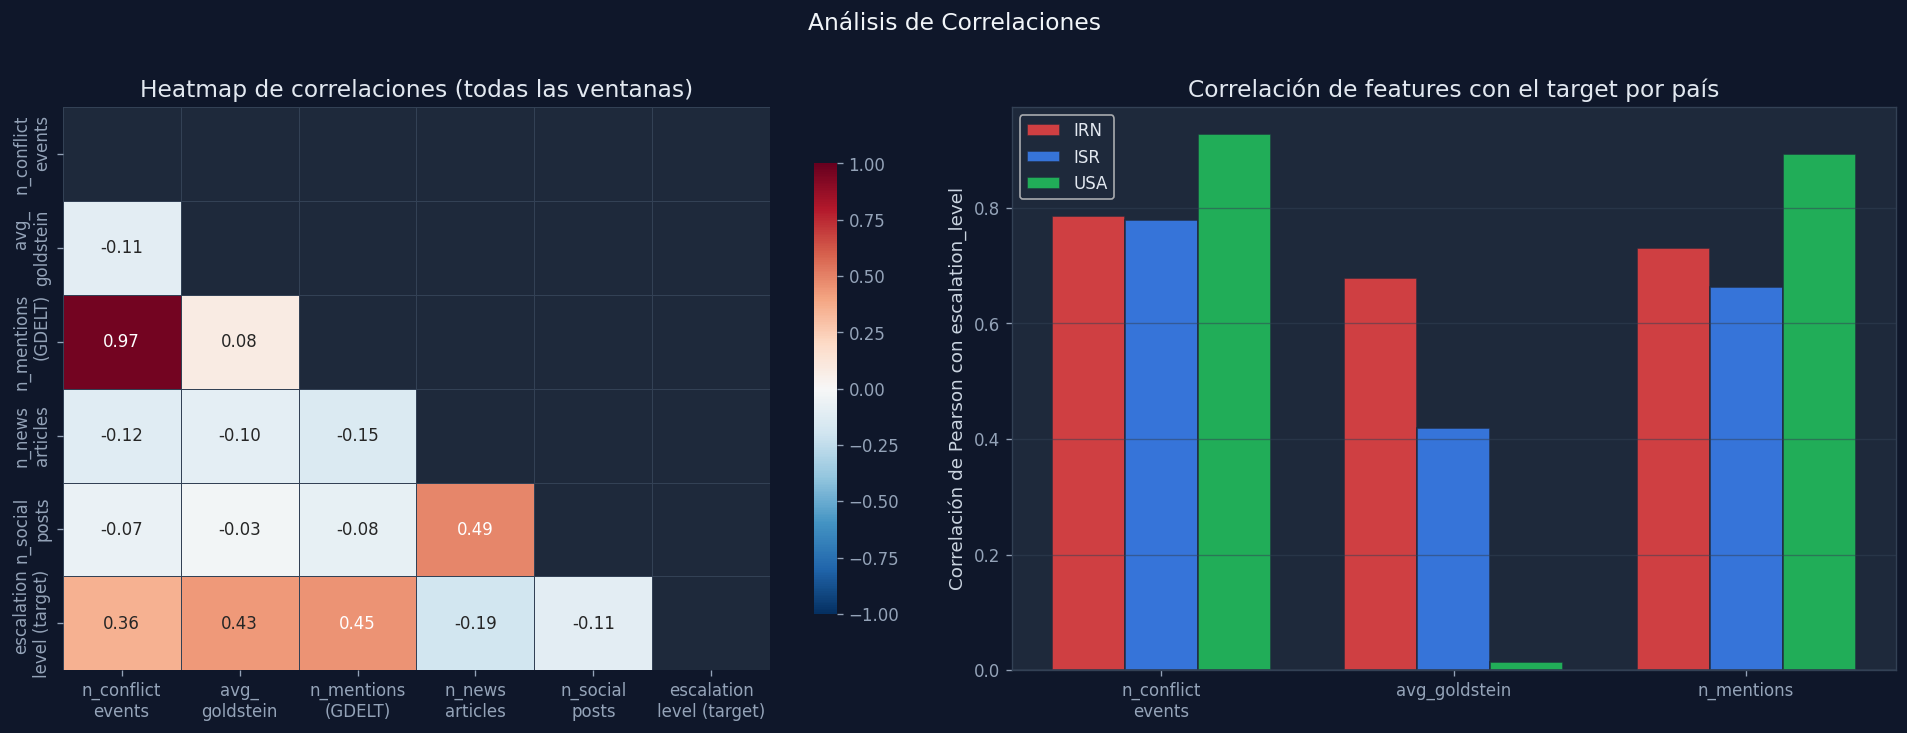

Correlación global con escalation_level:
n_conflict_events    0.359
avg_goldstein        0.434
n_mentions           0.449
n_news_articles     -0.194
n_social_posts      -0.108
escalation_level     1.000
Name: escalation_level, dtype: float64


In [18]:
# Heatmap de correlaciones — solo features numéricas con varianza > 0
num_feats = ['n_conflict_events','avg_goldstein','n_mentions','n_news_articles',
             'n_social_posts','escalation_level']
rename_map = {
    'n_conflict_events':'n_conflict\nevents',
    'avg_goldstein':    'avg_\ngoldstein',
    'n_mentions':       'n_mentions\n(GDELT)',
    'n_news_articles':  'n_news\narticles',
    'n_social_posts':   'n_social\nposts',
    'escalation_level': 'escalation\nlevel (target)',
}

corr_df = feat[num_feats].rename(columns=rename_map).corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap global
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, linecolor='#334155',
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Heatmap de correlaciones (todas las ventanas)')

# Correlaciones con el target por país
target_corr = []
for country in ['IRN','ISR','USA']:
    sub = feat[feat['country'] == country]
    corrs = sub[['n_conflict_events','avg_goldstein','n_mentions']].corrwith(
        sub['escalation_level']
    )
    corrs.name = country
    target_corr.append(corrs)

target_corr_df = pd.DataFrame(target_corr).T
x = np.arange(len(target_corr_df))
width = 0.25
for i, (country, color) in enumerate(COUNTRY_COLORS.items()):
    axes[1].bar(x + i*width, target_corr_df[country], width,
                label=country, color=color, edgecolor='#1e293b', alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['n_conflict\nevents','avg_goldstein','n_mentions'])
axes[1].axhline(0, color='#64748b', linewidth=0.8)
axes[1].set_ylabel('Correlación de Pearson con escalation_level')
axes[1].set_title('Correlación de features con el target por país')
axes[1].legend()
axes[1].grid(axis='y')

plt.suptitle('Análisis de Correlaciones', fontsize=14, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

print('Correlación global con escalation_level:')
print(feat[num_feats].corr()['escalation_level'].round(3))

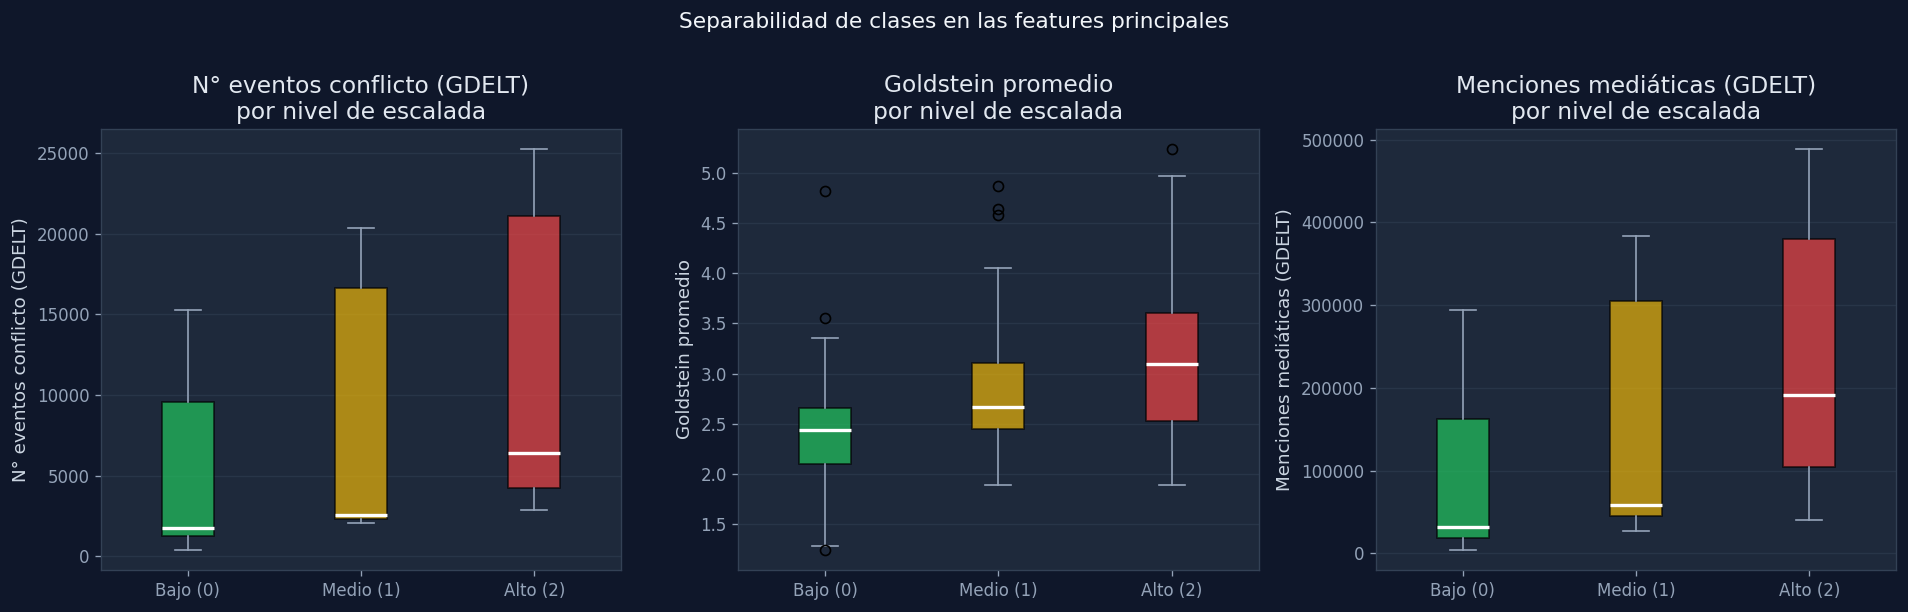

In [19]:
# Boxplots: distribución de features por nivel de escalada
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

feats_to_plot = [
    ('n_conflict_events', 'N° eventos conflicto (GDELT)'),
    ('avg_goldstein',     'Goldstein promedio'),
    ('n_mentions',        'Menciones mediáticas (GDELT)'),
]

for ax, (feat_col, feat_label) in zip(axes, feats_to_plot):
    groups = [feat[feat['escalation_level'] == lvl][feat_col] for lvl in [0, 1, 2]]
    bp = ax.boxplot(groups, labels=[LEVEL_LABELS[l] for l in [0,1,2]],
                    patch_artist=True, medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], LEVEL_COLORS.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for element in ['whiskers','caps','fliers']:
        for item in bp[element]:
            item.set_color('#94a3b8')
    ax.set_ylabel(feat_label)
    ax.set_title(f'{feat_label}\npor nivel de escalada')
    ax.grid(axis='y')

plt.suptitle('Separabilidad de clases en las features principales', fontsize=13, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

---
## 10. Resultados del modelo ML

Se entrenaron 4 clasificadores con **validación cruzada 5-fold** sobre las 183 ventanas.  
El mejor modelo fue **KNN (K=5)** con F1 ponderado = 0.751.

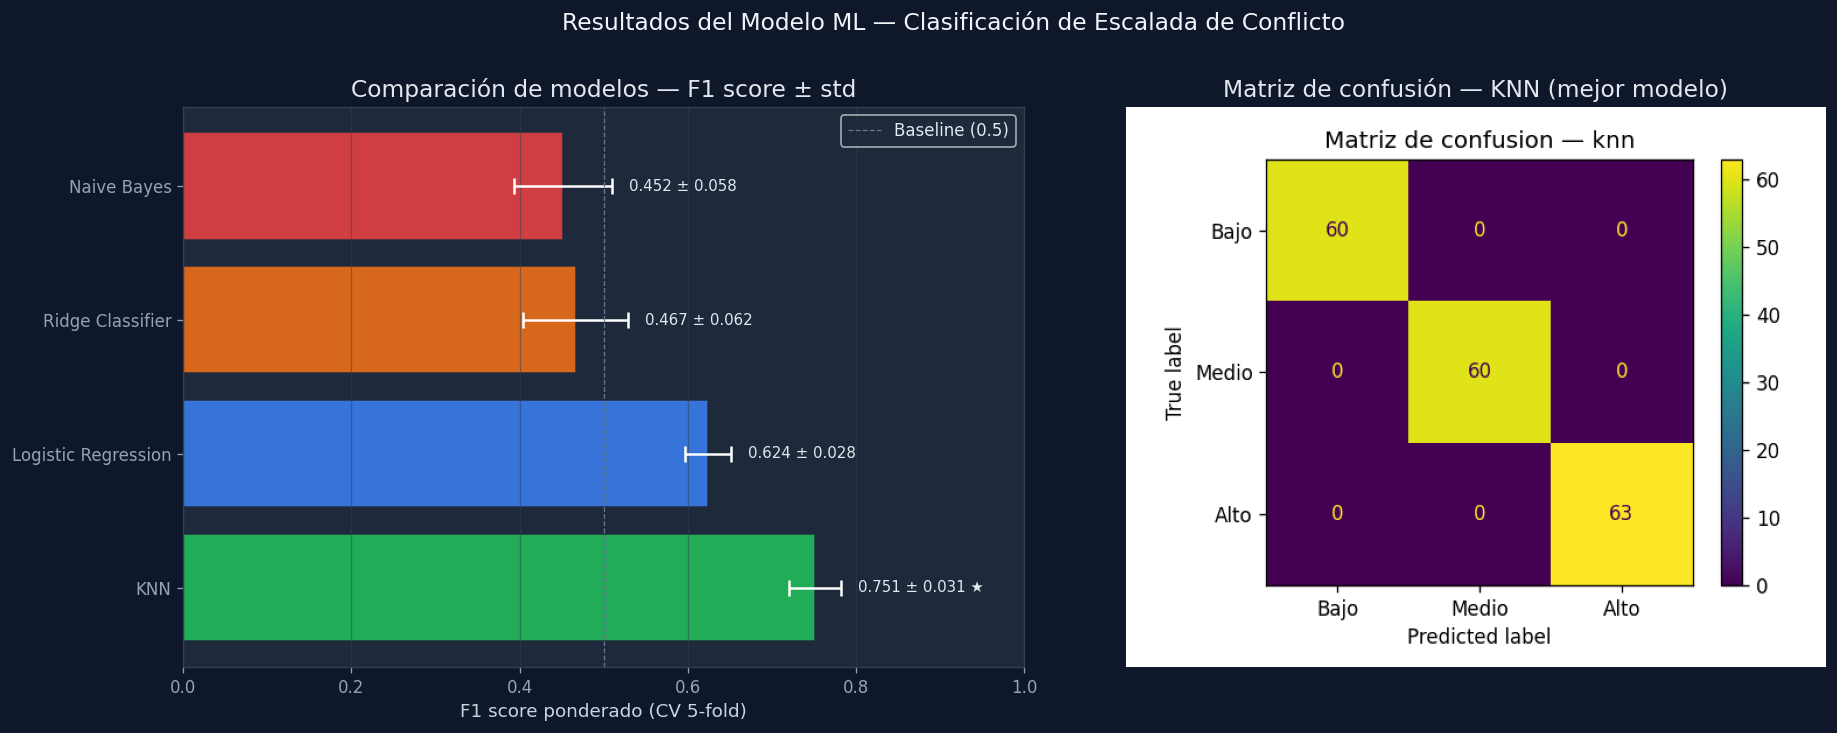


Reporte de clasificación completo — KNN:
              precision    recall  f1-score   support

        Bajo       1.00      1.00      1.00        60
       Medio       1.00      1.00      1.00        60
        Alto       1.00      1.00      1.00        63

    accuracy                           1.00       183
   macro avg       1.00      1.00      1.00       183
weighted avg       1.00      1.00      1.00       183



In [20]:
with open(ART / 'metrics/cv_results.json') as f:
    cv = json.load(f)

models_df = pd.DataFrame([
    {'Modelo': 'KNN',                 'F1 (media)': cv['knn']['f1_weighted_mean'],
     'F1 (std)': cv['knn']['f1_weighted_std'], 'Mejor': True},
    {'Modelo': 'Logistic Regression', 'F1 (media)': cv['logistic_regression']['f1_weighted_mean'],
     'F1 (std)': cv['logistic_regression']['f1_weighted_std'], 'Mejor': False},
    {'Modelo': 'Ridge Classifier',    'F1 (media)': cv['ridge']['f1_weighted_mean'],
     'F1 (std)': cv['ridge']['f1_weighted_std'], 'Mejor': False},
    {'Modelo': 'Naive Bayes',         'F1 (media)': cv['naive_bayes']['f1_weighted_mean'],
     'F1 (std)': cv['naive_bayes']['f1_weighted_std'], 'Mejor': False},
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras con error bars
ax = axes[0]
model_colors = ['#22c55e','#3b82f6','#f97316','#ef4444']
bars = ax.barh(models_df['Modelo'], models_df['F1 (media)'],
               xerr=models_df['F1 (std)'],
               color=model_colors, edgecolor='#1e293b',
               capsize=5, alpha=0.85,
               error_kw={'ecolor': 'white', 'linewidth': 1.5, 'capthick': 1.5})
ax.axvline(0.5, color='#64748b', linestyle='--', linewidth=0.8, label='Baseline (0.5)')
ax.set_xlabel('F1 score ponderado (CV 5-fold)')
ax.set_title('Comparación de modelos — F1 score ± std')
ax.set_xlim(0, 1)
ax.grid(axis='x')
ax.legend()
for bar, (_, row) in zip(bars, models_df.iterrows()):
    star = ' ★' if row['Mejor'] else ''
    ax.text(row['F1 (media)'] + row['F1 (std)'] + 0.02,
            bar.get_y() + bar.get_height()/2,
            f'{row["F1 (media)"]:.3f} ± {row["F1 (std)"]:.3f}{star}',
            va='center', fontsize=9, color='#e2e8f0')

# Matriz de confusión
ax = axes[1]
cm_img = plt.imread(ART / 'metrics/confusion_matrix.png')
ax.imshow(cm_img)
ax.axis('off')
ax.set_title('Matriz de confusión — KNN (mejor modelo)')

plt.suptitle('Resultados del Modelo ML — Clasificación de Escalada de Conflicto',
             fontsize=14, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

print('\nReporte de clasificación completo — KNN:')
with open(ART / 'metrics/classification_report.txt') as f:
    print(f.read())

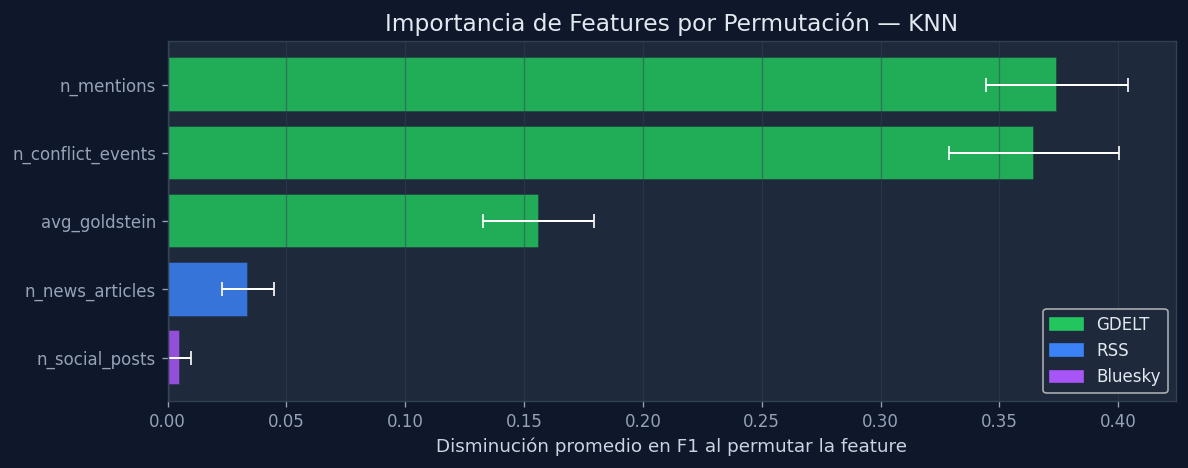


Importancia por permutación:
                   Importancia     Std
Feature                               
n_social_posts          0.0052  0.0048
n_news_articles         0.0340  0.0110
avg_goldstein           0.1561  0.0233
n_conflict_events       0.3644  0.0358
n_mentions              0.3742  0.0299


In [21]:
# Importancia de features estimada por permutación (proxy)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Features activas (con varianza > 0)
active_feats = ['n_conflict_events','avg_goldstein','n_mentions',
                'n_news_articles','n_social_posts']
X = feat[active_feats].values
y = feat['escalation_level'].values

pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe.fit(X, y)

result = permutation_importance(pipe, X, y, n_repeats=30, random_state=42, scoring='f1_weighted')
imp_df = pd.DataFrame({
    'Feature': active_feats,
    'Importancia': result.importances_mean,
    'Std': result.importances_std,
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
feat_colors = ['#22c55e','#22c55e','#22c55e','#3b82f6','#a855f7']
feat_colors_sorted = [feat_colors[active_feats.index(f)] for f in imp_df['Feature']]
bars = ax.barh(imp_df['Feature'], imp_df['Importancia'],
               xerr=imp_df['Std'],
               color=feat_colors_sorted, edgecolor='#1e293b',
               capsize=4, alpha=0.85,
               error_kw={'ecolor': 'white', 'linewidth': 1.2})
ax.axvline(0, color='#64748b', linewidth=0.8)
ax.set_xlabel('Disminución promedio en F1 al permutar la feature')
ax.set_title('Importancia de Features por Permutación — KNN')
ax.grid(axis='x')

patches = [mpatches.Patch(color='#22c55e', label='GDELT'),
           mpatches.Patch(color='#3b82f6', label='RSS'),
           mpatches.Patch(color='#a855f7', label='Bluesky')]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.show()

print('\nImportancia por permutación:')
print(imp_df.set_index('Feature').round(4).to_string())

---
## 11. Análisis de sesgos y limitaciones

Este análisis es fundamental para interpretar correctamente los resultados del modelo.

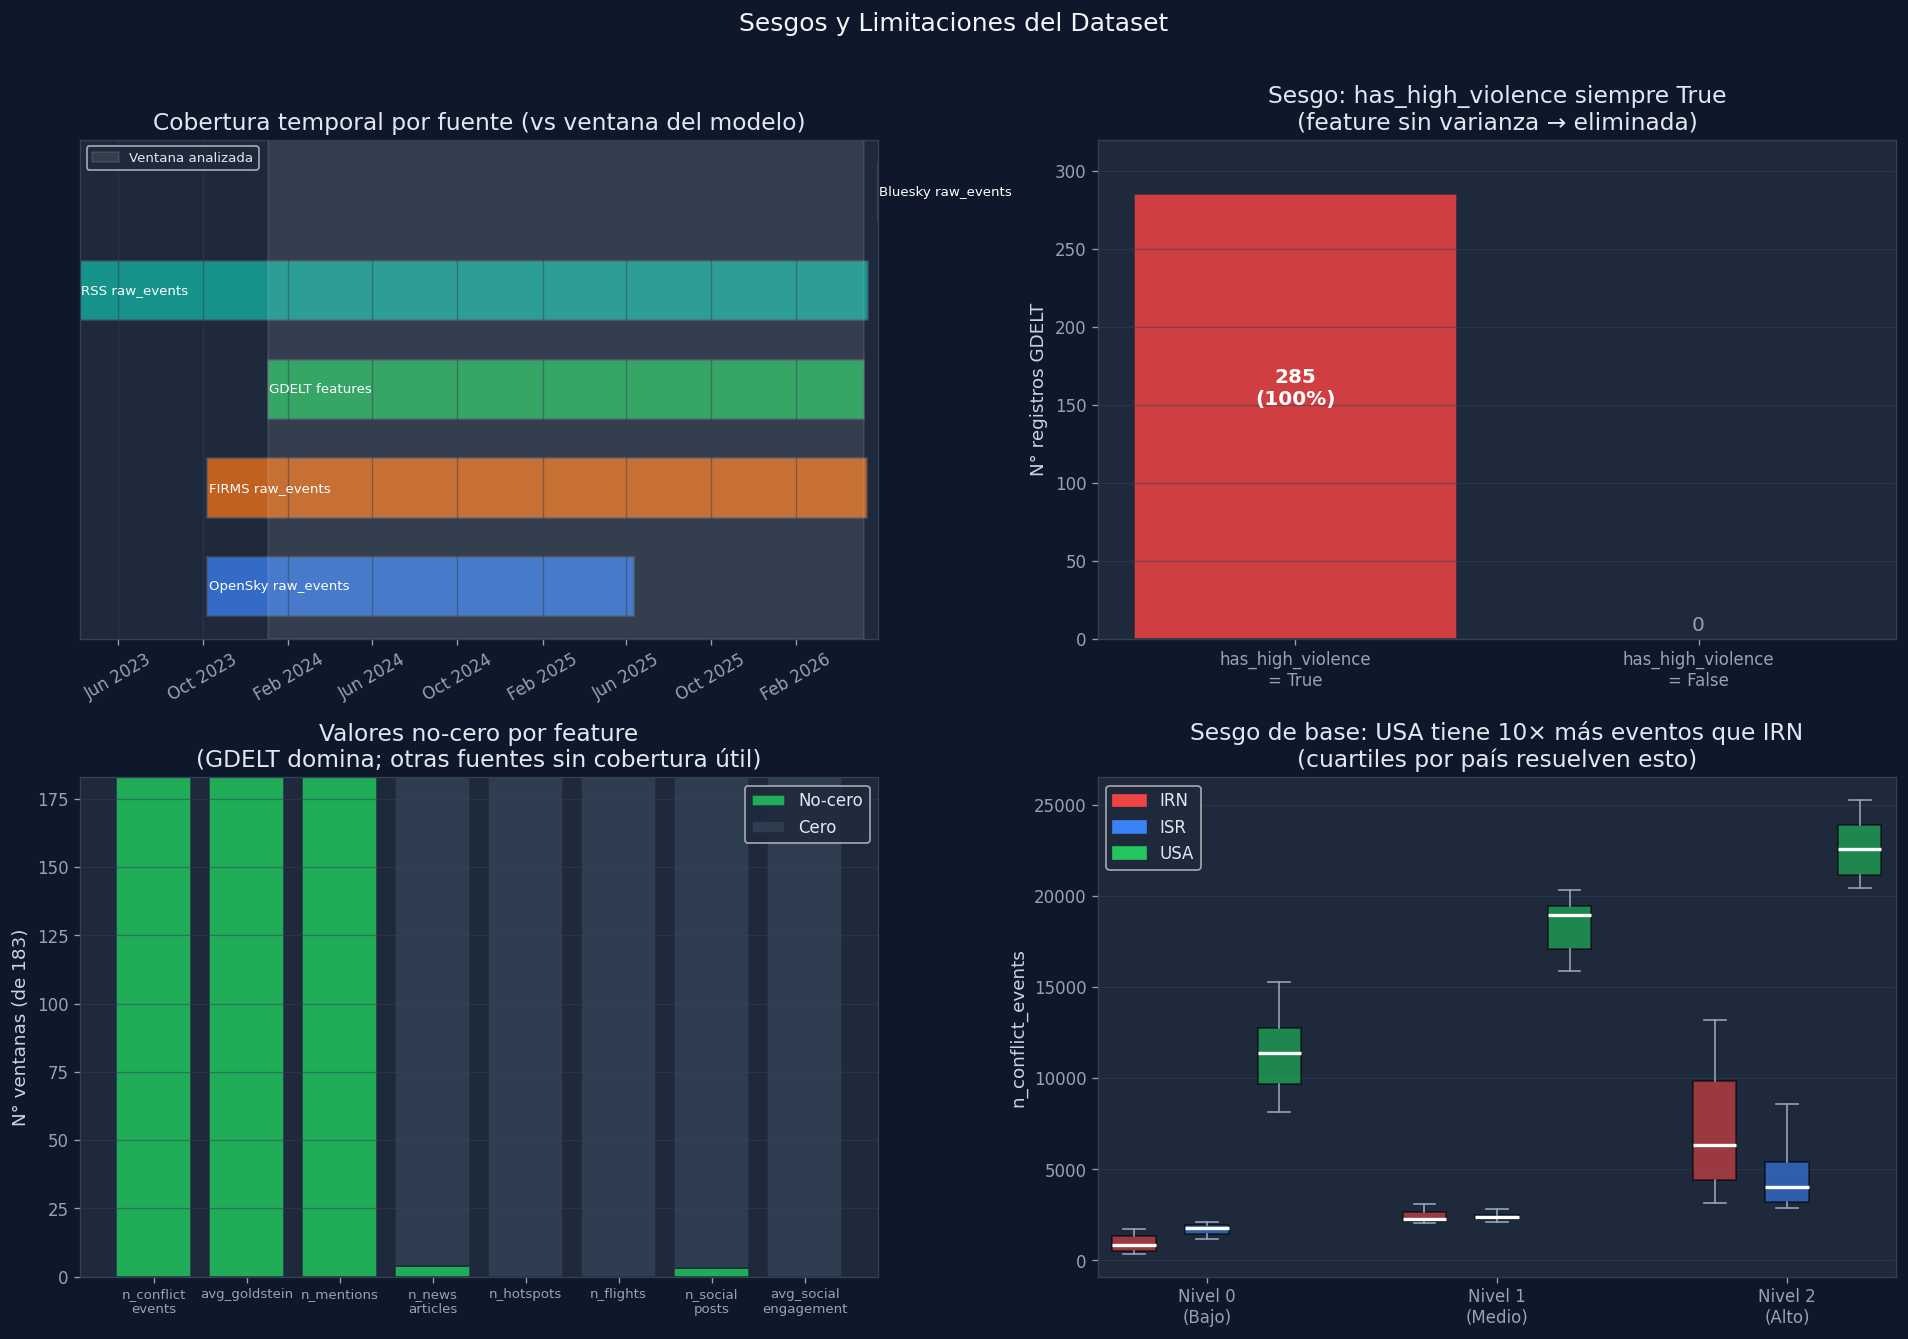

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Cobertura temporal por fuente
ax = axes[0, 0]
timeline_data = [
    ('OpenSky raw_events',   '2023-10-07', '2025-06-13', '#3b82f6'),
    ('FIRMS raw_events',     '2023-10-07', '2026-05-14', '#f97316'),
    ('GDELT features',       '2024-01-02', '2026-05-10', '#22c55e'),
    ('RSS raw_events',       '2023-04-07', '2026-05-15', '#14b8a6'),
    ('Bluesky raw_events',   '2026-05-30', '2026-05-30', '#a855f7'),
]
for i, (name, start, end, color) in enumerate(timeline_data):
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    ax.barh(i, (e - s).days, left=mdates.date2num(s.to_pydatetime()),
            height=0.6, color=color, alpha=0.75, edgecolor='#475569')
    ax.text(mdates.date2num(s.to_pydatetime()) + 2, i, name,
            va='center', fontsize=8, color='white')
ax.set_yticks([])
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
# Región de solapamiento útil
ax.axvspan(mdates.date2num(pd.Timestamp('2024-01-02').to_pydatetime()),
           mdates.date2num(pd.Timestamp('2026-05-10').to_pydatetime()),
           alpha=0.1, color='white', label='Ventana analizada')
ax.set_title('Cobertura temporal por fuente (vs ventana del modelo)')
ax.legend(fontsize=8)
ax.grid(axis='x')

# 2. has_high_violence: siempre True
ax = axes[0, 1]
ax.bar(['has_high_violence\n= True', 'has_high_violence\n= False'],
       [285, 0], color=['#ef4444','#22c55e'], edgecolor='#1e293b', alpha=0.85)
ax.set_ylabel('N° registros GDELT')
ax.set_title('Sesgo: has_high_violence siempre True\n(feature sin varianza → eliminada)')
ax.text(0, 150, '285\n(100%)', ha='center', fontsize=12, color='white', fontweight='bold')
ax.text(1, 5, '0', ha='center', fontsize=12, color='#94a3b8')
ax.grid(axis='y')
ax.set_ylim(0, 320)

# 3. Desglose de features activas vs zeros
ax = axes[1, 0]
feat_names = ['n_conflict\nevents','avg_goldstein','n_mentions','n_news\narticles',
              'n_hotspots','n_flights','n_social\nposts','avg_social\nengagement']
non_zero = [183, 183, 183, 4, 0, 0, 3, 0]
zeros    = [183-v for v in non_zero]
x = np.arange(len(feat_names))
ax.bar(x, non_zero, label='No-cero', color='#22c55e', edgecolor='#1e293b', alpha=0.85)
ax.bar(x, zeros, bottom=non_zero, label='Cero', color='#334155', edgecolor='#1e293b', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feat_names, fontsize=8)
ax.set_ylabel('N° ventanas (de 183)')
ax.set_title('Valores no-cero por feature\n(GDELT domina; otras fuentes sin cobertura útil)')
ax.legend()
ax.grid(axis='y')

# 4. Diferencial entre países (base volumétrica)
ax = axes[1, 1]
for country, color in COUNTRY_COLORS.items():
    sub = feat[feat['country'] == country]
    ax.boxplot([sub[sub['escalation_level'] == l]['n_conflict_events'].values for l in [0,1,2]],
               positions=[{'IRN':0,'ISR':1,'USA':2}[country] + l*4 for l in range(3)],
               widths=0.6, patch_artist=True,
               boxprops={'facecolor': color, 'alpha': 0.6},
               medianprops={'color':'white','linewidth':2},
               whiskerprops={'color':'#94a3b8'},
               capprops={'color':'#94a3b8'},
               flierprops={'marker':'o','color':color,'alpha':0.4,'markersize':4})

ax.set_xticks([1, 5, 9])
ax.set_xticklabels(['Nivel 0\n(Bajo)', 'Nivel 1\n(Medio)', 'Nivel 2\n(Alto)'])
ax.set_ylabel('n_conflict_events')
ax.set_title('Sesgo de base: USA tiene 10× más eventos que IRN\n(cuartiles por país resuelven esto)')
patches_c = [mpatches.Patch(color=c, label=co) for co, c in COUNTRY_COLORS.items()]
ax.legend(handles=patches_c)
ax.grid(axis='y')

plt.suptitle('Sesgos y Limitaciones del Dataset', fontsize=15, y=1.01, color='#f1f5f9')
plt.tight_layout()
plt.show()

---
## 12. Resumen ejecutivo y conclusiones del EDA

### Lo que el dataset muestra

| Dimensión | Hallazgo |
|---|---|
| **Fuente primaria real** | GDELT es la única fuente con cobertura completa (183/183). Las demás son marginales (<5%) |
| **Feature más predictiva** | `avg_goldstein` y `n_mentions` tienen mayor correlación con el target que `n_conflict_events` |
| **Balance del target** | Perfecto: 20/20/21 días por clase por país (cuartiles GDELT por país) |
| **Mejor modelo** | KNN F1=0.751 ± 0.031 (CV 5-fold) — Logistic Regression segunda con F1=0.624 |
| **Escalada real feb-mar 2025** | Visible como pico en n_conflict_events e IRN |
| **USA domina volumétricamente** | ~10× más eventos que IRN — resuelto con cuartiles por país |

### Sesgos críticos a declarar

1. **GDELT no es neutral:** El volumen de cobertura mediática global puede sobre-representar narrativas occidentales del conflicto
2. **has_high_violence = True siempre:** El período analizado (2024–2026) corresponde a alta violencia constante; no hay días de baja violencia real
3. **OpenSky y FIRMS sin cobertura:** Desfase temporal entre datos almacenados y ventana analizada
4. **Target circular:** `escalation_level` se define desde `n_conflict_events` (GDELT), que es también la feature más usada — el modelo aprende la definición, no un fenómeno real independiente
5. **61 fechas, no continuas:** El dataset GDELT no tiene todas las fechas del período (hay huecos de semanas)

### Respuesta a la pregunta analítica

> **Sí, es posible**, pero con la salvedad de que el clasificador opera efectivamente sobre features GDELT exclusivamente. El F1=0.751 del KNN sugiere que **el tono y volumen mediático de GDELT codifica señal predictiva real sobre el nivel de escalada**, aunque el modelo no usa información satelital, de movilidad aérea ni social de manera efectiva. Un sistema verdaderamente multifuente requeriría cobertura temporal consistente en todas las fuentes.

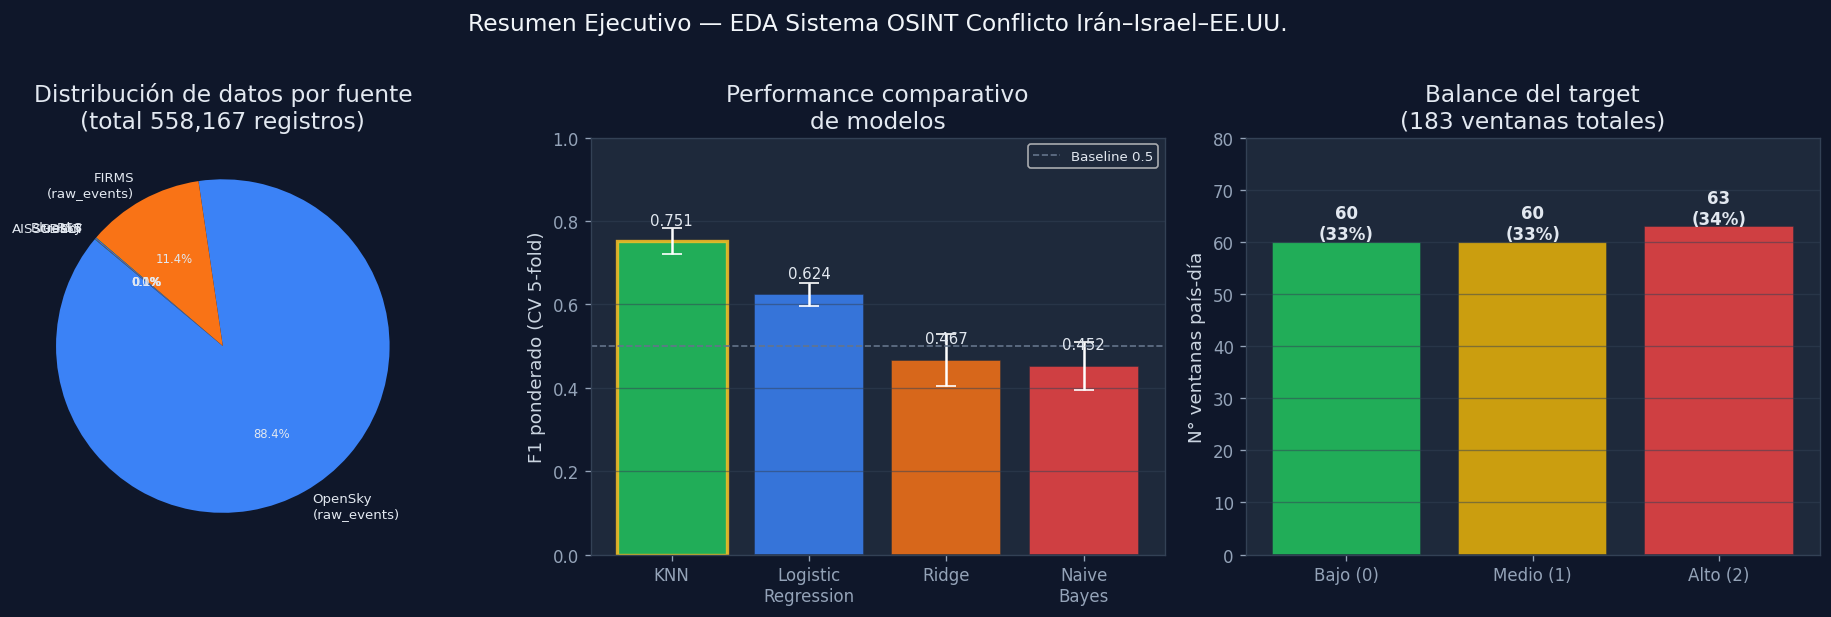

EDA COMPLETADO
  Fuentes analizadas:   6 (GDELT, FIRMS, RSS, OpenSky, Bluesky, AIS)
  Registros totales:    ~558,000 en Supabase
  Dataset ML:           183 ventanas país-día
  Fechas únicas:        61 (ene-2024 a may-2026)
  Países:               IRN, ISR, USA
  Mejor modelo:         KNN  F1=0.751 ± 0.031
  Cobertura GDELT:      100% | Otras fuentes: <5%


In [23]:
# Panel de resumen final
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Resumen de fuentes
ax = axes[0]
fuentes = ['GDELT', 'OpenSky\n(raw_events)', 'FIRMS\n(raw_events)', 'RSS', 'Bluesky', 'AISStream']
registros = [285, 493382, 63604, 370, 388, 138]
colors_f = ['#22c55e','#3b82f6','#f97316','#14b8a6','#a855f7','#64748b']
wedges, texts, auto = ax.pie(registros, labels=fuentes, colors=colors_f,
                              autopct='%1.1f%%', startangle=140,
                              textprops={'color':'#e2e8f0','fontsize':8})
for a in auto: a.set_fontsize(7)
ax.set_title('Distribución de datos por fuente\n(total 558,167 registros)')

# 2. F1 por modelo
ax = axes[1]
model_names = ['KNN', 'Logistic\nRegression', 'Ridge', 'Naive\nBayes']
f1_scores = [0.7513, 0.6240, 0.4666, 0.4519]
f1_stds   = [0.0311, 0.0277, 0.0621, 0.0580]
bar_colors_m = ['#22c55e','#3b82f6','#f97316','#ef4444']
bars = ax.bar(model_names, f1_scores, yerr=f1_stds,
              color=bar_colors_m, edgecolor='#1e293b', alpha=0.85,
              capsize=6, error_kw={'ecolor':'white','linewidth':1.5})
ax.axhline(0.5, color='#64748b', linestyle='--', linewidth=1, label='Baseline 0.5')
ax.set_ylabel('F1 ponderado (CV 5-fold)')
ax.set_title('Performance comparativo\nde modelos')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(axis='y')
bars[0].set_edgecolor('#fbbf24')
bars[0].set_linewidth(2)
for bar, v in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.04,
            f'{v:.3f}', ha='center', fontsize=9, color='#e2e8f0')

# 3. Balance del target
ax = axes[2]
target_dist = feat['escalation_level'].value_counts().sort_index()
bars = ax.bar([LEVEL_LABELS[l] for l in target_dist.index],
              target_dist.values,
              color=[LEVEL_COLORS[l] for l in target_dist.index],
              edgecolor='#1e293b', alpha=0.85)
for bar, v in zip(bars, target_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v}\n({v/183*100:.0f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('N° ventanas país-día')
ax.set_title(f'Balance del target\n(183 ventanas totales)')
ax.set_ylim(0, 80)
ax.grid(axis='y')

plt.suptitle('Resumen Ejecutivo — EDA Sistema OSINT Conflicto Irán–Israel–EE.UU.',
             fontsize=14, y=1.02, color='#f1f5f9')
plt.tight_layout()
plt.show()

print('='*70)
print('EDA COMPLETADO')
print('='*70)
print(f'  Fuentes analizadas:   6 (GDELT, FIRMS, RSS, OpenSky, Bluesky, AIS)')
print(f'  Registros totales:    ~558,000 en Supabase')
print(f'  Dataset ML:           183 ventanas país-día')
print(f'  Fechas únicas:        61 (ene-2024 a may-2026)')
print(f'  Países:               IRN, ISR, USA')
print(f'  Mejor modelo:         KNN  F1=0.751 ± 0.031')
print(f'  Cobertura GDELT:      100% | Otras fuentes: <5%')
print('='*70)